In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import pyam
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np

In [48]:
curpol = pd.read_excel('D:/COMMITTED/Models/NEST-Pakistan/submission9/CurPol.xlsx')
ndc_cond = pd.read_excel('D:/COMMITTED/Models/NEST-Pakistan/submission9/NDC-cond.xlsx')
lts = pd.read_excel('D:/COMMITTED/Models/NEST-Pakistan/submission9/LTS.xlsx')
ndc_uncond = pd.read_excel('D:/COMMITTED/Models/NEST-Pakistan/submission9/NDC-uncond.xlsx')

In [49]:
rep_all = pyam.concat([curpol, ndc_cond, ndc_uncond, lts])

In [6]:
# rep_all.filter(variable = 'Emissio*Kyoto*').plot()

<Axes: xlabel='Year', ylabel='Mt CO2-equiv/yr'>

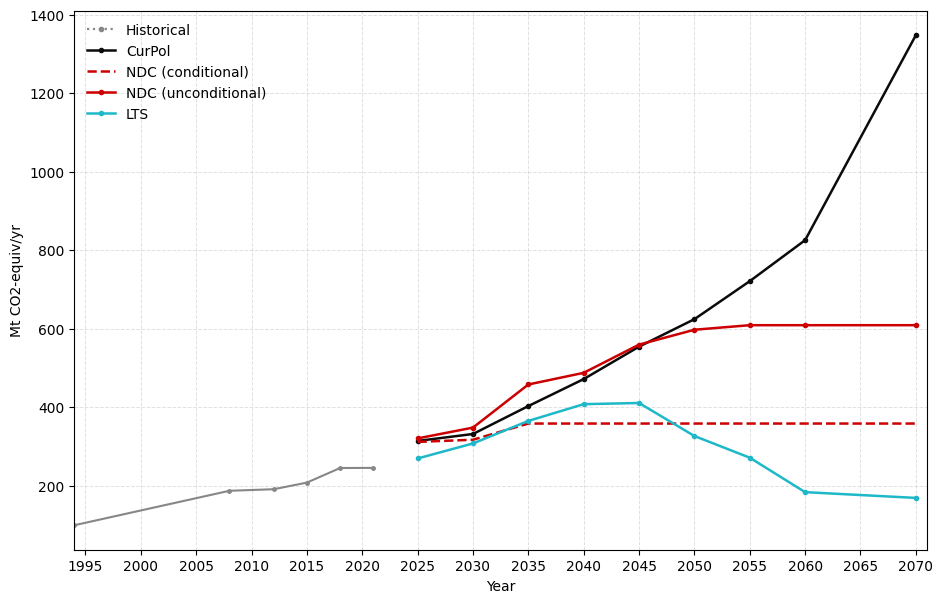

In [44]:
palette = {
    "CurPol":   "#0B0B0B",
    "LTS":      "#1eb8c9",
    "NDC-cond":   "#CC0000",  
    "NDC-uncond": "#CC0000",  
}

linestyles = {
    "NDC-cond":   "--",
    "NDC-uncond": "-",
}

markers = {
    # "NDC-cond":   "o",
    "NDC-uncond": "o",
    "LTS": "o",
    "CurPol": "o",

}

ax = None
fig, ax = plt.subplots(figsize=(11, 7))
for scen in ["CurPol","NDC-uncond","NDC-cond","LTS"]:
    df = rep_all.filter(variable="Emissions|Kyoto*", scenario=scen)
    ax = df.plot(
        ax=ax,
        color=palette.get(scen, "#999999"),
        linewidth=1.8,
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=3,
        legend=False
    )
# External timeseries (years + values). Replace with your full list:
ext_years  = [1994, 2008, 2012, 2015,2018,2021]
ext_values = [99.0265, 186.8265, 190.791, 207.7, 244.9, 245.2]  # paste your values here

# If your source is in TWh, convert: EJ = TWh * 3.6e-3
# ext_values = np.array(ext_values) * 3.6e-3

ax.plot(
    ext_years, ext_values,
    marker="o", markersize=2.5,
    linewidth=1.5, color="#878787",
    label="Historical"
)

# widen x-limits so the historic years are visible
ax.set_xlim(min(ext_years), 2071)
ax.set_xticks(np.arange(1995, 2071, 5))

ax.grid(which="major", axis="both", color="lightgrey", alpha=0.7, linestyle="--", linewidth=0.7)

handles = [
    Line2D([0],[0], color="#878787", lw=1.6, ls=":", marker="o", markersize=3, label="Historical"),
    Line2D([0],[0], color=palette["CurPol"],   lw=1.8, marker="o", markersize=3, label="CurPol"),
    Line2D([0],[0], color=palette["NDC-cond"], lw=1.8, ls="--", label="NDC (conditional)"),
    Line2D([0],[0], color=palette["NDC-uncond"], lw=1.8, ls="-",  marker="o", markersize=3, label="NDC (unconditional)"),
    Line2D([0],[0], color=palette["LTS"],     lw=1.8, marker="o", markersize=3, label="LTS"),
]
ax.legend(handles=handles, frameon=False, loc="upper left")
ax.set_title("")

ax

<Axes: xlabel='Year', ylabel='EJ / yr'>

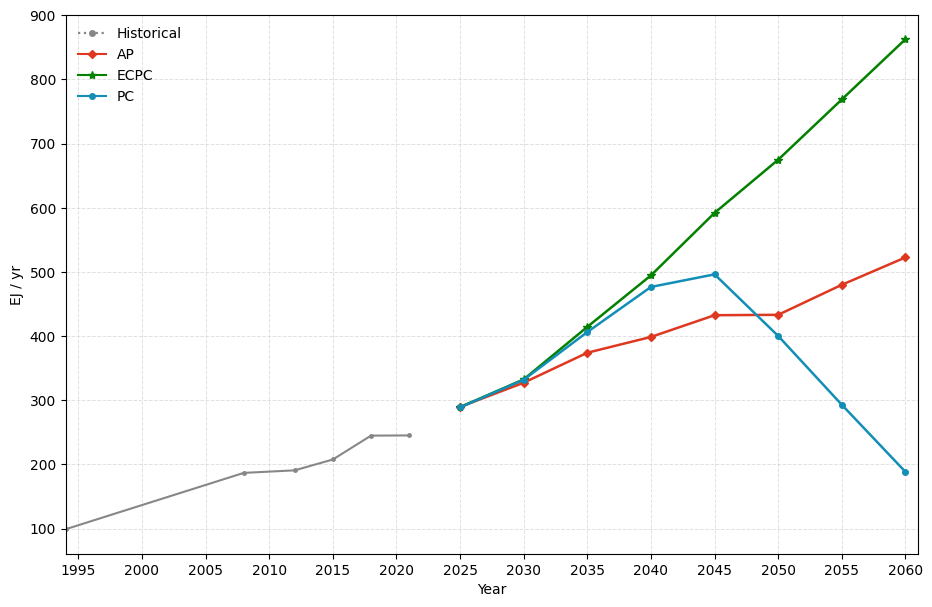

In [304]:
palette = {
    "AP":   "#DF3821",
    "PC":   "#128EB7",
    "ECPC": "#048100",  
}



markers = {
    "ECPC": "*",
    "PC": "o",
    "AP": "D",

}

ax = None
fig, ax = plt.subplots(figsize=(11, 7))

for scen in ["AP", "ECPC","PC"]:
    df = rep_all.filter(variable="Emissions|Kyoto*", scenario=scen)
    ax = df.plot(
        ax=ax,
        color=palette.get(scen, "#999999"),
        linewidth=1.8,
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=6 if scen=="ECPC" else 4,
        legend=False
    )
# External timeseries (years + values). Replace with your full list:
ext_years  = [1994, 2008, 2012, 2015,2018,2021]
ext_values = [99.0265, 186.8265, 190.791, 207.7, 244.9, 245.2]  # paste your values here

# If your source is in TWh, convert: EJ = TWh * 3.6e-3
# ext_values = np.array(ext_values) * 3.6e-3

ax.plot(
    ext_years, ext_values,
    marker="o", markersize=2.5,
    linewidth=1.5, color="#878787",
    label="Historical"
)

# widen x-limits so the historic years are visible
ax.set_xlim(min(ext_years), 2061)
ax.set_xticks(np.arange(1995, 2065, 5))

ax.grid(which="major", axis="both", color="lightgrey", alpha=0.7, linestyle="--", linewidth=0.7)

handles = [
    Line2D([0],[0], color="#878787", lw=1.6, ls=":", marker="o", markersize=4, label="Historical"),
    Line2D([0],[0], color=palette["AP"],   lw=1.5, marker="D", markersize=4, label="AP"),
    Line2D([0],[0], color=palette["ECPC"], lw=1.5, marker="*", markersize=6, label="ECPC"),
    Line2D([0],[0], color=palette["PC"],     lw=1.5, marker="o", markersize=4, label="PC"),
]
ax.legend(handles=handles, frameon=False, loc="upper left")
ax.set_title("")
ax.set_ylabel("EJ / yr")
ax

In [10]:
# import matplotlib.pyplot as plt
# from matplotlib.lines import Line2D
# import numpy as np

# fig, ax = plt.subplots(figsize=(8,5))

# # Historical series only
# ext_years  = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
# ext_values = [0.362102,0.357462,0.355158,0.380513,0.392612,0.410734,
#               0.434238,0.480936,0.493268,0.483269,0.516917,0.554602,
#               0.498740,0.493906]

# ax.plot(
#     ext_years, ext_values,
#     marker="o", markersize=3,
#     linewidth=1.6, color="#4d4d4d",
#     linestyle="--",
#     label="Historical Generation"
# )

# # Format axes
# ax.set_xlim(min(ext_years), max(ext_years))
# ax.set_xticks(np.arange(2010, 2026, 2))
# ax.set_ylabel("EJ / yr")
# ax.set_title("Historical Electricity Generation")

# # Add grid for readability
# ax.grid(axis="y", linestyle="--", alpha=0.6)

# # Legend
# ax.legend(frameon=False, loc="upper left")

# plt.show()


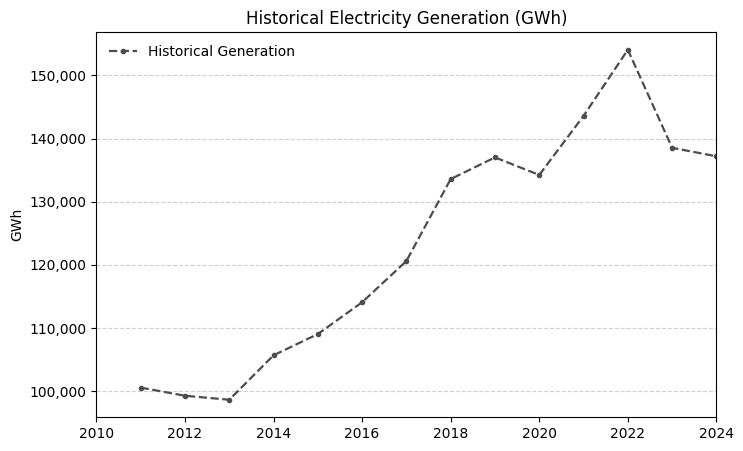

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

fig, ax = plt.subplots(figsize=(8,5))

# Historical series only
ext_years  = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
ext_values_ej = [0.362102,0.357462,0.355158,0.380513,0.392612,0.410734,
                 0.434238,0.480936,0.493268,0.483269,0.516917,0.554602,
                 0.498740,0.493906]

FACTOR_EJ_TO_GWH = 277_777.7777778
ext_values_gwh = (np.array(ext_values_ej) * FACTOR_EJ_TO_GWH).tolist()

ax.plot(
    ext_years, ext_values_gwh,
    marker="o", markersize=3,
    linewidth=1.6, color="#4d4d4d",
    linestyle="--",
    label="Historical Generation"
)

# Format axes
ax.set_xlim(min(ext_years), max(ext_years))
ax.set_xticks(np.arange(2010, 2026, 2))
ax.set_ylabel("GWh")
ax.set_title("Historical Electricity Generation (GWh)")

# Add grid for readability
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Optional: thousands separators on y-axis
ax.get_yaxis().set_major_formatter(lambda x, pos: f"{x:,.0f}")

# Legend
ax.legend(frameon=False, loc="upper left")

plt.show()


### SE Policy Scenarios

<Axes: xlabel='Year', ylabel='EJ / yr'>

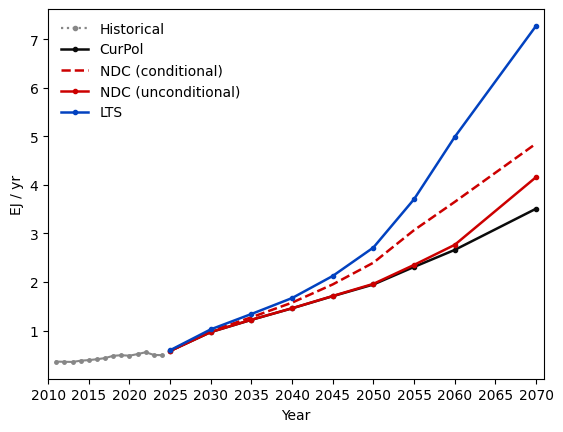

In [12]:
palette = {
    "CurPol":   "#0B0B0B",
    "LTS":      "#0242C0",
    "NDC-cond":   "#CC0000",  
    "NDC-uncond": "#CC0000",  
}

linestyles = {
    "NDC-cond":   "--",
    "NDC-uncond": "-",
}

markers = {
    # "NDC-cond":   "o",
    "NDC-uncond": "o",
    "LTS": "o",
    "CurPol": "o",

}

ax = None
for scen in ["CurPol","NDC-uncond","NDC-cond","LTS"]:
    df = rep_all.filter(variable="Secondary Energy|Electricity", scenario=scen)
    ax = df.plot(
        ax=ax,
        color=palette.get(scen, "#999999"),
        linewidth=1.8,
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=3,
        legend=False
    )
# External timeseries (years + values). Replace with your full list:
ext_years  = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
ext_values = [0.362102,0.357462,0.355158,0.380513,0.392612,0.410734,
              0.434238,0.480936,0.493268,0.483269,0.516917,0.554602,
              0.498740,0.493906]  # paste your values here

# If your source is in TWh, convert: EJ = TWh * 3.6e-3
# ext_values = np.array(ext_values) * 3.6e-3

ax.plot(
    ext_years, ext_values,
    marker="o", markersize=2.5,
    linewidth=1.5, color="#878787",
    label="Historical"
)

# widen x-limits so the historic years are visible
ax.set_xlim(min(ext_years), 2071)
ax.set_xticks(np.arange(2010, 2071, 5))

handles = [
    Line2D([0],[0], color="#878787", lw=1.6, ls=":", marker="o", markersize=3, label="Historical"),
    Line2D([0],[0], color=palette["CurPol"],   lw=1.8, marker="o", markersize=3, label="CurPol"),
    Line2D([0],[0], color=palette["NDC-cond"], lw=1.8, ls="--", label="NDC (conditional)"),
    Line2D([0],[0], color=palette["NDC-uncond"], lw=1.8, ls="-",  marker="o", markersize=3, label="NDC (unconditional)"),
    Line2D([0],[0], color=palette["LTS"],     lw=1.8, marker="o", markersize=3, label="LTS"),
]
ax.legend(handles=handles, frameon=False, loc="upper left")
ax.set_title("")
ax.set_ylabel("EJ / yr")
ax

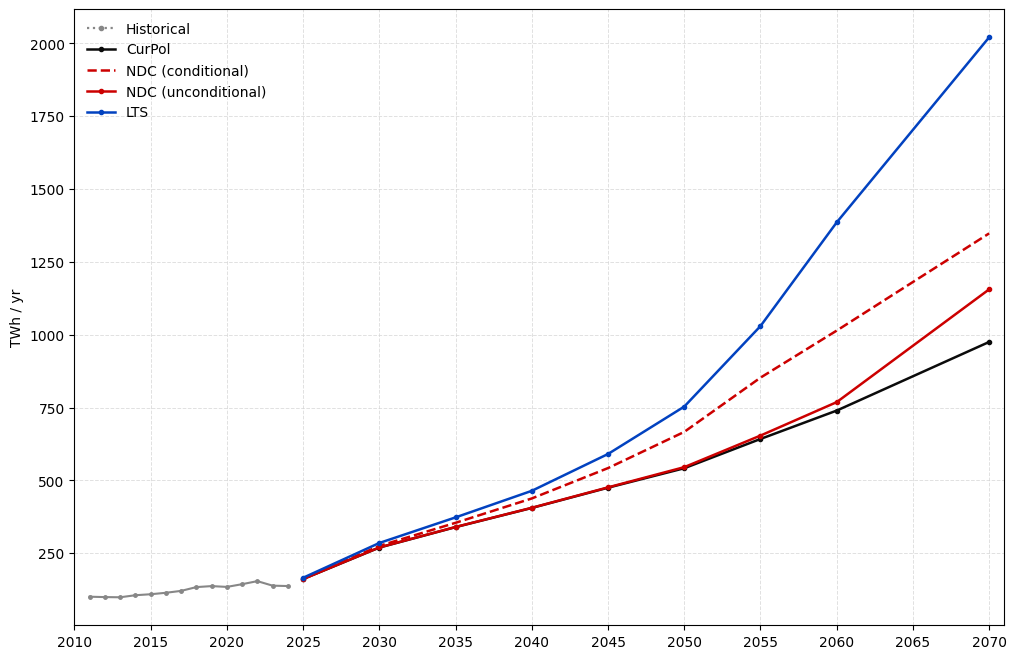

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

EJ_to_GWh = 277.778  # 1 EJ = 277,778 GWh

palette = {"CurPol":"#0B0B0B","LTS":"#0242C0","NDC-cond":"#CC0000","NDC-uncond":"#CC0000"}
linestyles = {"NDC-cond":"--","NDC-uncond":"-"}
markers    = {"CurPol":"o","LTS":"o","NDC-uncond":"o"}

fig, ax = plt.subplots(figsize=(12, 8))

for scen in ["CurPol","NDC-uncond","NDC-cond","LTS"]:
    ts = rep_all.filter(variable="Secondary Energy|Electricity", scenario=scen).timeseries()
    if ts.empty:
        continue
    # robust if multiple rows (regions/techs): sum across rows
    ts_sum = ts.sum(axis=0)
    years  = ts_sum.index.astype(int)
    vals_gwh = ts_sum.values * EJ_to_GWh

    ax.plot(
        years, vals_gwh,
        color=palette.get(scen, "#999999"),
        linewidth=1.8,
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=3,
        label=scen if scen != "NDC-uncond" else "NDC (unconditional)"
    )

# Historical series → GWh
ext_years  = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
ext_values = [0.362102,0.357462,0.355158,0.380513,0.392612,0.410734,0.434238,0.480936,
              0.493268,0.483269,0.516917,0.554602,0.498740,0.493906]
ax.plot(ext_years, np.array(ext_values)*EJ_to_GWh,
       marker="o", markersize=2.5, linewidth=1.5, color="#878787", label="Historical")

# Axes & grid
ax.set_xlim(min(ext_years), 2071)
ax.set_xticks(np.arange(2010, 2071, 5))
ax.set_ylabel("TWh / yr")
ax.grid(which="major", axis="both", color="lightgrey", alpha=0.7, linestyle="--", linewidth=0.7)

# Legend (pretty labels for NDC)
handles = [
    Line2D([0],[0], color="#878787", lw=1.6, ls=":", marker="o", markersize=3, label="Historical"),
    Line2D([0],[0], color=palette["CurPol"],   lw=1.8, marker="o", markersize=3, label="CurPol"),
    Line2D([0],[0], color=palette["NDC-cond"], lw=1.8, ls="--", label="NDC (conditional)"),
    Line2D([0],[0], color=palette["NDC-uncond"], lw=1.8, ls="-", marker="o", markersize=3, label="NDC (unconditional)"),
    Line2D([0],[0], color=palette["LTS"],     lw=1.8, marker="o", markersize=3, label="LTS"),
]
ax.legend(handles=handles, frameon=False, loc="upper left")

plt.show()


In [ ]:
zorder = {"ECPC":1, "AP":2, "PC":2, "NDC-uncond":3, "NDC-cond":3, "LTS":4, "CurPol":5}
ax = None
for scen in ["CurPol","NDC-uncond","NDC-cond","LTS","AP","ECPC","PC"]:
    df = rep_all.filter(variable="Secondary Energy|Electricity", scenario=scen)
    ax = df.plot(
        ax=ax,
        color=palette.get(scen, "#999999"),
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=9 if scen=="ECPC" else 6,
        markevery=[-1],     # marker at last year
        linewidth=1.8 if scen=="ECPC" else 1.4,
        zorder=zorder.get(scen, 2),
        legend=False
    )
# External timeseries (years + values). Replace with your full list:
ext_years  = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
ext_values = [0.362102,0.357462,0.355158,0.380513,0.392612,0.410734,
              0.434238,0.480936,0.493268,0.483269,0.516917,0.554602,
              0.498740,0.493906]  # paste your values here

# If your source is in TWh, convert: EJ = TWh * 3.6e-3
# ext_values = np.array(ext_values) * 3.6e-3

ax.plot(
    ext_years, ext_values,
    marker="o", markersize=2.5,
    linewidth=1.6, color="#878787", zorder=10,
    label="Historic (2011–2024)"
)

# widen x-limits so the historic years are visible
ax.set_xlim(min(ext_years), 2061)
ax.set_xticks(np.arange(2010, 2065, 5))

handles = [
    Line2D([0],[0], color="#2ca02c", lw=1.6, ls=":", marker="o", label="Historic (2011–2024)"),
    Line2D([0],[0], color=palette["CurPol"],   lw=1.4, label="CurPol"),
    Line2D([0],[0], color=palette["NDC-cond"], lw=1.4, ls="--", marker="o", label="NDC (conditional)"),
    Line2D([0],[0], color=palette["NDC-uncond"], lw=1.4, ls="-",  marker="s", label="NDC (unconditional)"),
    Line2D([0],[0], color=palette["LTS"],     lw=1.4, label="LTS"),
    Line2D([0],[0], color=palette["AP"],      lw=1.4, marker="D", label="AP"),
    Line2D([0],[0], color=palette["ECPC"],    lw=1.4, marker="*", markersize=9, label="ECPC"),
    Line2D([0],[0], color=palette["PC"],      lw=1.4, marker="o", label="PC"),
]
ax.legend(handles=handles, frameon=False, ncol=2, loc="upper left")
ax.set_title("")
ax.set_ylabel("EJ / yr")
ax

<Axes: xlabel='Year', ylabel='EJ / yr'>

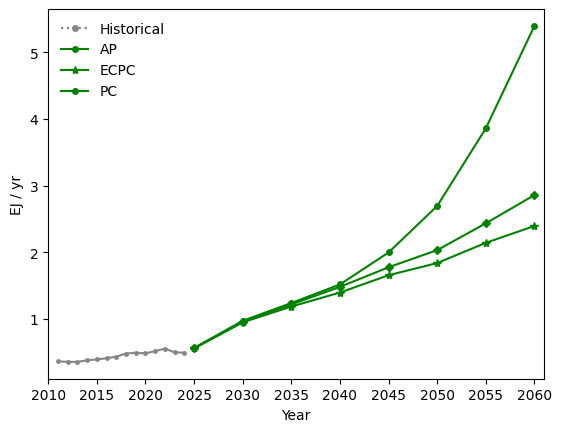

In [133]:
palette = {
    "AP":   "#048100",
    "PC":   "#048100",
    "ECPC": "#048100",  
}



markers = {
    "ECPC": "*",
    "PC": "o",
    "AP": "D",

}

ax = None
for scen in ["AP", "ECPC","PC"]:
    df = rep_all.filter(variable="Secondary Energy|Electricity", scenario=scen)
    ax = df.plot(
        ax=ax,
        color=palette.get(scen, "#999999"),
        linewidth=1.5,
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=6 if scen=="ECPC" else 4,
        legend=False
    )
# External timeseries (years + values). Replace with your full list:
ext_years  = [2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
ext_values = [0.362102,0.357462,0.355158,0.380513,0.392612,0.410734,
              0.434238,0.480936,0.493268,0.483269,0.516917,0.554602,
              0.498740,0.493906]  # paste your values here

# If your source is in TWh, convert: EJ = TWh * 3.6e-3
# ext_values = np.array(ext_values) * 3.6e-3

ax.plot(
    ext_years, ext_values,
    marker="o", markersize=2.5,
    linewidth=1.5, color="#878787",
    label="Historical"
)

# widen x-limits so the historic years are visible
ax.set_xlim(min(ext_years), 2061)
ax.set_xticks(np.arange(2010, 2065, 5))

handles = [
    Line2D([0],[0], color="#878787", lw=1.6, ls=":", marker="o", markersize=4, label="Historical"),
    Line2D([0],[0], color=palette["AP"],   lw=1.5, marker="o", markersize=4, label="AP"),
    Line2D([0],[0], color=palette["ECPC"], lw=1.5, marker="*", markersize=6, label="ECPC"),
    Line2D([0],[0], color=palette["PC"],     lw=1.5, marker="o", markersize=4, label="PC"),
]
ax.legend(handles=handles, frameon=False, loc="upper left")
ax.set_title("")
ax.set_ylabel("EJ / yr")
ax

<Axes: xlabel='Year', ylabel='EJ / yr'>

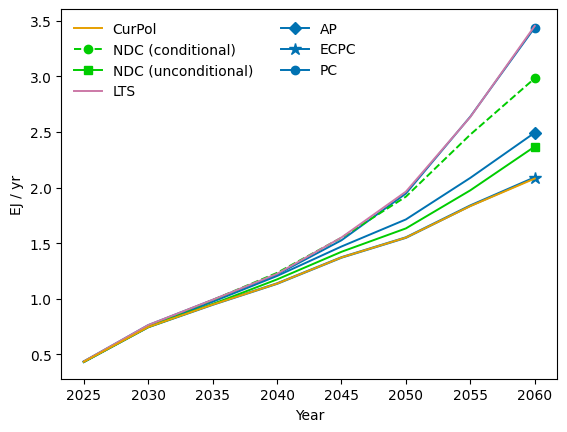

In [66]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

zorder = {"ECPC":1, "AP":2, "PC":2, "NDC-uncond":3, "NDC-cond":3, "LTS":4, "CurPol":5}
ax = None
for scen in ["CurPol","NDC-uncond","NDC-cond","LTS","AP","ECPC","PC"]:
    df = rep_all.filter(variable="Final Energy|Electricity", scenario=scen)
    ax = df.plot(
        ax=ax,
        color=palette.get(scen, "#999999"),
        linestyle=linestyles.get(scen, "-"),
        marker=markers.get(scen, None),
        markersize=9 if scen=="ECPC" else 6,
        markevery=[-1],     # marker at last year
        linewidth=1.8 if scen=="ECPC" else 1.4,
        zorder=zorder.get(scen, 2),
        legend=False
    )

# custom legend
handles = [
    Line2D([0],[0], color=palette["CurPol"],   lw=1.4, label="CurPol"),
    Line2D([0],[0], color=palette["NDC-cond"], lw=1.4, ls="--", marker="o", label="NDC (conditional)"),
    Line2D([0],[0], color=palette["NDC-uncond"], lw=1.4, ls="-",  marker="s", label="NDC (unconditional)"),
    Line2D([0],[0], color=palette["LTS"],     lw=1.4, label="LTS"),
    Line2D([0],[0], color=palette["AP"],      lw=1.4, marker="D", label="AP"),
    Line2D([0],[0], color=palette["ECPC"],    lw=1.4, marker="*", markersize=9, label="ECPC"),
    Line2D([0],[0], color=palette["PC"],      lw=1.4, marker="o", label="PC"),
]
ax.legend(handles=handles, frameon=False, ncol=2, loc="upper left")
ax.set_title("")
ax.set_ylabel("EJ / yr")
ax


<Axes: title={'center': 'model: MESSAGEix-Pakistan 1 - region: Pakistan - variable: Final Energy|Electricity'}, xlabel='Year', ylabel='EJ/yr'>

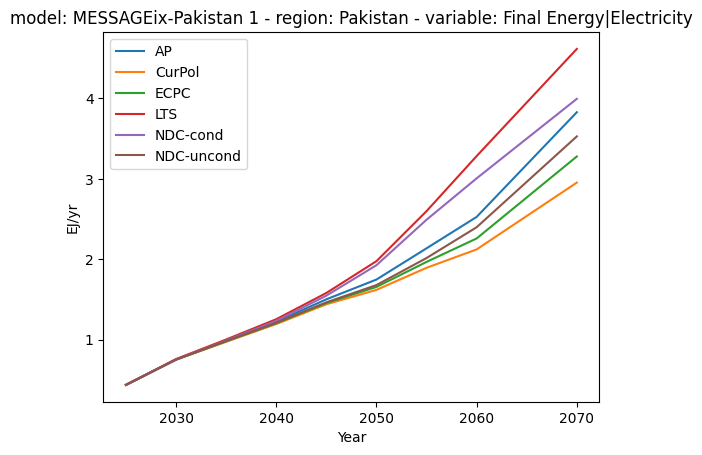

In [7]:
rep_all.filter(variable = 'Final Energy|Electricity').plot(color = 'scenario')

In [8]:
# rep_all.filter(variable = 'Capacity|Electricity|Coal').plot()

### Technology Capacities

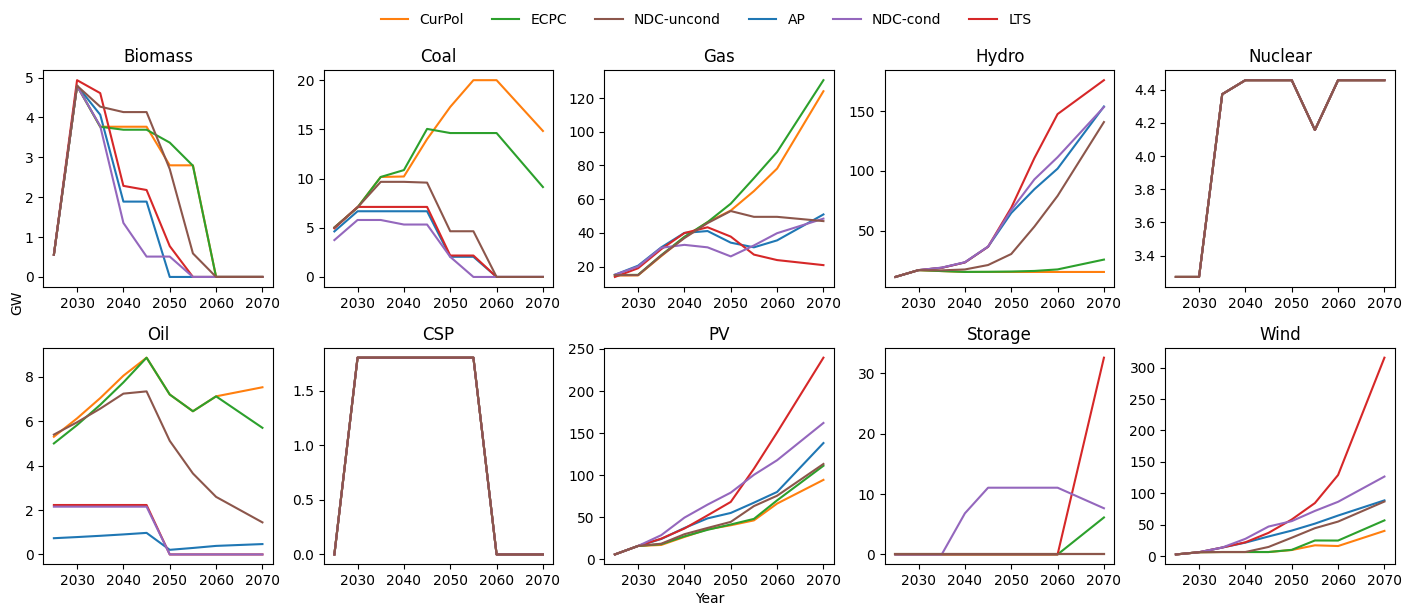

In [9]:
variables = [
"Capacity|Electricity|Biomass",
"Capacity|Electricity|Coal",
"Capacity|Electricity|Gas",

"Capacity|Electricity|Hydro",
"Capacity|Electricity|Nuclear",
"Capacity|Electricity|Oil",

"Capacity|Electricity|Solar|CSP",
"Capacity|Electricity|Solar|PV",
"Capacity|Electricity|Storage",
"Capacity|Electricity|Wind",
]


fig, axes = plt.subplots(
    nrows=2,
    ncols=5, 
    figsize=(14, 6), 
    # sharex=True
)

axes = axes.flatten()

# plot each variable in its respective subplot
for ax, var in zip(axes, variables):
    rep_all.filter(variable=var).plot(ax=ax, color='scenario', legend=False)
    ax.set_title(var.split('|')[-1])  # Optional: cleaner subplot titles
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.text(0.5, 0.00001, 'Year', ha='center', fontsize=10)  # Lowered from 0.04 to 0.01
fig.text(0.0001, 0.5, 'GW', va='center', rotation='vertical', fontsize=10)  # Left-padded more

# create a single shared legend
custom_order = ['CurPol', 'ECPC', "NDC-uncond", 'AP', 'NDC-cond', 'LTS']

# Get current handles and labels
handles, labels = axes[0].get_legend_handles_labels()

# Create a dict to map label to handle
label_to_handle = dict(zip(labels, handles))

# Reorder handles and labels
ordered_handles = [label_to_handle[label] for label in custom_order if label in label_to_handle]
ordered_labels = [label for label in custom_order if label in label_to_handle]

# Draw the legend with your custom order
fig.legend(ordered_handles, ordered_labels, loc='upper center', ncol=len(ordered_labels), frameon=False)

# set common X and Y labels
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
plt.show()

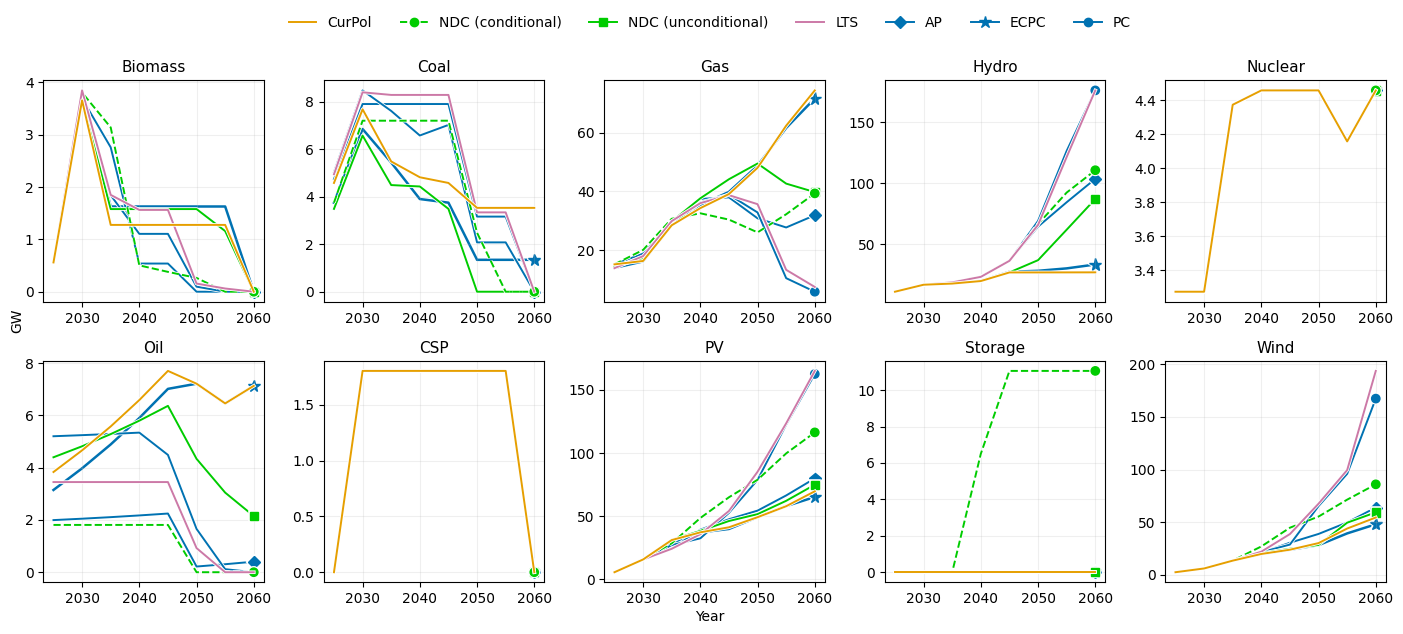

In [67]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

variables = [
    "Capacity|Electricity|Biomass",
    "Capacity|Electricity|Coal",
    "Capacity|Electricity|Gas",
    "Capacity|Electricity|Hydro",
    "Capacity|Electricity|Nuclear",
    "Capacity|Electricity|Oil",
    "Capacity|Electricity|Solar|CSP",
    "Capacity|Electricity|Solar|PV",
    "Capacity|Electricity|Storage",
    "Capacity|Electricity|Wind",
]

# ---- your style dicts (keep exactly as in your final script) ----
palette = {
    "CurPol":   "#E69F00",
    "AP":       "#0072B2",
    "ECPC":     "#0072B2",
    "PC":       "#0072B2",
    "LTS":      "#CC79A7",
    "NDC-cond": "#00CC00",
    "NDC-uncond": "#00CC00",
}
linestyles = {"NDC-cond": "--", "NDC-uncond": "-"}
markers = {"NDC-cond":"o","NDC-uncond":"s","AP":"D","ECPC":"*","PC":"o"}
zorder = {"ECPC":1, "AP":2, "PC":2, "NDC-uncond":3, "NDC-cond":3, "LTS":4, "CurPol":5}
order   = ["CurPol","NDC-uncond","NDC-cond","LTS","AP","ECPC","PC"]

outline = [pe.Stroke(linewidth=2.6, foreground="white"), pe.Normal()]

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 6), sharex=False, sharey=False)
axes = axes.flatten()

for ax, var in zip(axes, variables):
    for scen in order:
        df = rep_all.filter(variable=var, scenario=scen)
        if df.empty:   # skip scenarios not present for this variable
            continue
        df.plot(
            ax=ax,
            color=palette.get(scen, "#999999"),
            linestyle=linestyles.get(scen, "-"),
            marker=markers.get(scen, None),
            markersize=9 if scen=="ECPC" else 6,
            markevery=[-1],
            linewidth=1.8 if scen=="ECPC" else 1.4,
            zorder=zorder.get(scen, 2),
            legend=False,
            path_effects=outline,
        )
    ax.set_title(var.split("|")[-1], fontsize=11)  # neat short title
    ax.set_xlabel("")   # per-panel labels off (we add shared labels below)
    ax.set_ylabel("")
    ax.grid(True, alpha=0.2)

# shared axis labels
fig.text(0.5, 0.00001, "Year", ha="center", fontsize=10)
fig.text(0.0001, 0.5, "GW", va="center", rotation="vertical", fontsize=10)

# single shared legend (same order & styles as your other plots)
handles = [
    Line2D([0],[0], color=palette["CurPol"],   lw=1.4, label="CurPol"),
    Line2D([0],[0], color=palette["NDC-cond"], lw=1.4, ls="--", marker="o", label="NDC (conditional)"),
    Line2D([0],[0], color=palette["NDC-uncond"], lw=1.4, ls="-", marker="s", label="NDC (unconditional)"),
    Line2D([0],[0], color=palette["LTS"],     lw=1.4, label="LTS"),
    Line2D([0],[0], color=palette["AP"],      lw=1.4, marker="D", label="AP"),
    Line2D([0],[0], color=palette["ECPC"],    lw=1.4, marker="*", markersize=9, label="ECPC"),
    Line2D([0],[0], color=palette["PC"],      lw=1.4, marker="o", label="PC"),
]
fig.legend(handles=handles, loc="upper center", ncol=7, frameon=False, bbox_to_anchor=(0.5, 1.03))

plt.tight_layout(rect=[0, 0, 1, 0.96])  # space for legend
plt.show()


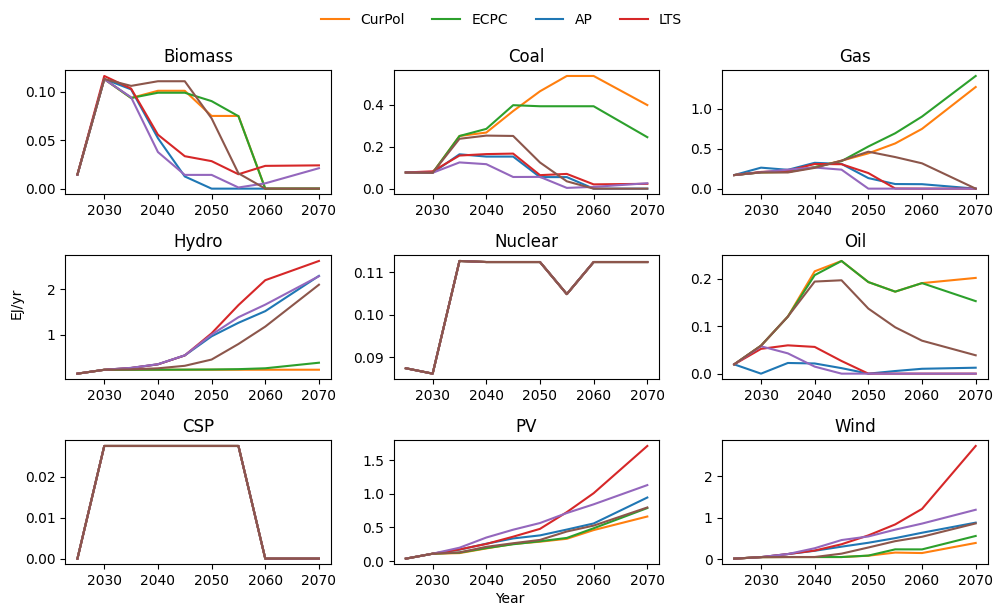

In [10]:
variables = [
"Secondary Energy|Electricity|Biomass",
"Secondary Energy|Electricity|Coal",
"Secondary Energy|Electricity|Gas",

"Secondary Energy|Electricity|Hydro",
"Secondary Energy|Electricity|Nuclear",
"Secondary Energy|Electricity|Oil",

"Secondary Energy|Electricity|Solar|CSP",
"Secondary Energy|Electricity|Solar|PV",
"Secondary Energy|Electricity|Wind",
]


fig, axes = plt.subplots(
    nrows=3,
    ncols=3, 
    figsize=(10, 6), 
    # sharex=True
)

axes = axes.flatten()

# plot each variable in its respective subplot
for ax, var in zip(axes, variables):
    rep_all.filter(variable=var).plot(ax=ax, color='scenario', legend=False)
    ax.set_title(var.split('|')[-1])  # Optional: cleaner subplot titles
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.text(0.5, 0.00001, 'Year', ha='center', fontsize=10)  # Lowered from 0.04 to 0.01
fig.text(0.0001, 0.5, 'EJ/yr', va='center', rotation='vertical', fontsize=10)  # Left-padded more

# create a single shared legend
custom_order = ['CurPol', 'ECPC', 'AP', 'NDC', 'LTS', 'LTS-2']

# Get current handles and labels
handles, labels = axes[0].get_legend_handles_labels()

# Create a dict to map label to handle
label_to_handle = dict(zip(labels, handles))

# Reorder handles and labels
ordered_handles = [label_to_handle[label] for label in custom_order if label in label_to_handle]
ordered_labels = [label for label in custom_order if label in label_to_handle]

# Draw the legend with your custom order
fig.legend(ordered_handles, ordered_labels, loc='upper center', ncol=len(ordered_labels), frameon=False)

# set common X and Y labels
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
plt.show()

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-Pakistan 1 scenario: PC region: Pakistan'}, xlabel='Year', ylabel='EJ/yr'>

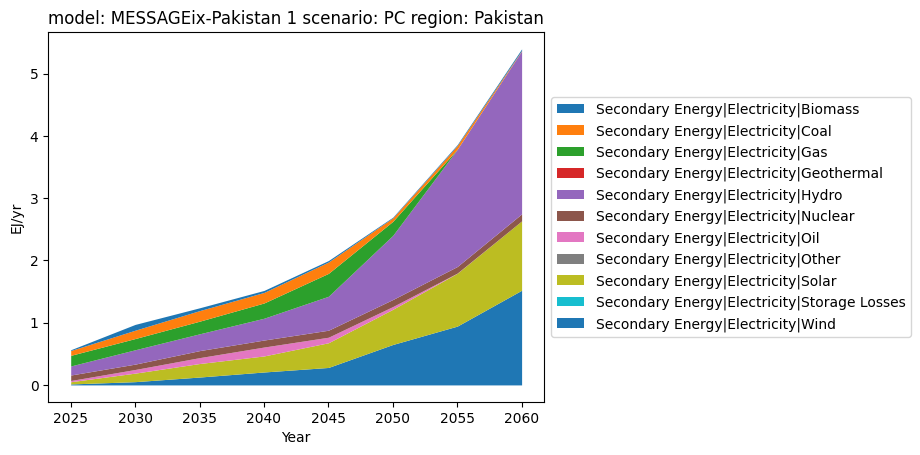

In [ ]:
vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses'
]
rep_all.filter(variable=vars_SE, scenario=scen).plot.stack()

### SE mix

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


Text(0.5, 1.0, 'Generation Mix at Secondary Level')

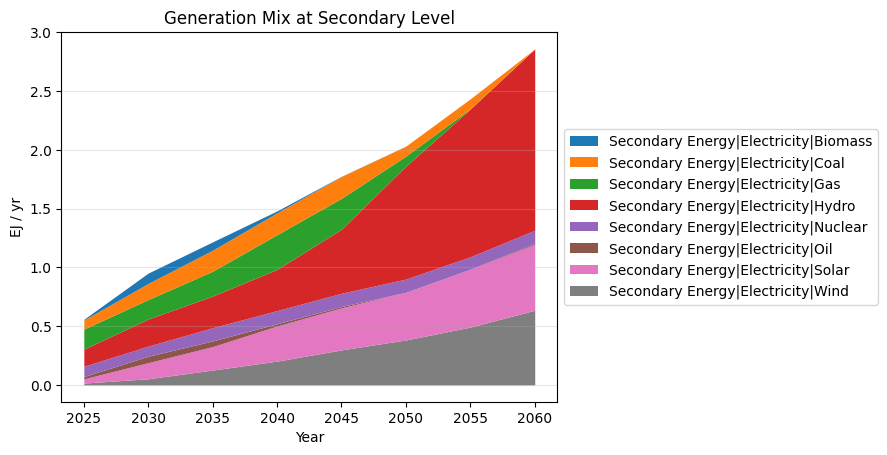

In [134]:
vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses'
]

vars_nonzero = []
for var in vars_SE:
    df = rep_all.filter(variable=var, scenario=scen).timeseries()
    if not (df == 0).all(axis=None):   # keep only if not all zero
        vars_nonzero.append(var)

ax = rep_all.filter(variable=vars_nonzero, scenario="AP").plot.stack()
ax.set_ylabel("EJ / yr")
ax.grid(alpha=0.3, axis="y")
ax.set_title("Generation Mix at Secondary Level")

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


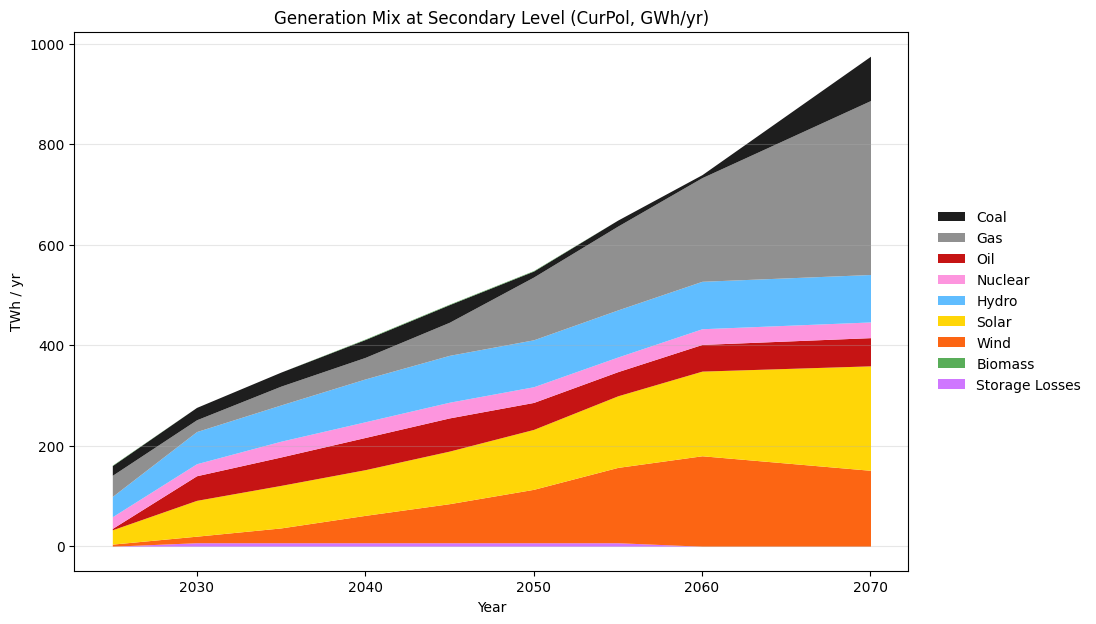

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from pyam import IamDataFrame
from pyam.plotting import run_control

# ----------------------------
# Inputs
# ----------------------------
vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses'
]

# Custom colors
run_control().update({
    "color": {
        "variable": {
            "Secondary Energy|Electricity|Biomass": "#59ad59",
            "Secondary Energy|Electricity|Coal":    "#1E1E1E",
            "Secondary Energy|Electricity|Gas":     "#909090",
            "Secondary Energy|Electricity|Hydro":   "#60bdff",
            "Secondary Energy|Electricity|Nuclear": "#fd95de",
            "Secondary Energy|Electricity|Oil":     "#c61414",
            "Secondary Energy|Electricity|Solar":   "#ffd607",
            "Secondary Energy|Electricity|Wind":    "#fc6513",
            "Secondary Energy|Electricity|Geothermal": "#9e9e9e",
            "Secondary Energy|Electricity|Other":      "#bdbdbd",
            "Secondary Energy|Electricity|Storage Losses": "#cf77ff",
        }
    }
})

# ----------------------------
# Prepare data (EJ/yr -> GWh/yr)
# ----------------------------
EJ_to_GWh = 277.778  # 1 EJ = 277,778 GWh

# Keep only non-zero variables for CurPol
vars_nonzero = []
for var in vars_SE:
    ts = rep_all.filter(variable=var, scenario="CurPol").timeseries()
    if len(ts) and not (ts == 0).all(axis=None):
        vars_nonzero.append(var)

# Filter CurPol data, convert units by scaling the long-format 'value'
curpol = rep_all.filter(variable=vars_nonzero, scenario="CurPol")
df_long = curpol.data.copy()                 # columns: model, scenario, region, variable, unit, year, value
df_long["value"] = df_long["value"] * EJ_to_GWh
df_long["unit"] = "GWh / yr"

curpol_gwh = IamDataFrame(df_long)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 7))

ax = curpol_gwh.plot.stack(
    order=vars_nonzero,   # consistent stacking & legend order
    legend=True,
    ax=ax
)

# Clean legend labels (keep only fuel names) and apply custom order
handles, labels = ax.get_legend_handles_labels()
labels = [lab.split("|")[-1] for lab in labels]  # -> 'Coal', 'Gas', ...

custom_order = [
    "Coal", "Gas", "Oil", "Nuclear", "Hydro", "Solar", "Wind", "Biomass", "Storage Losses"
]

ordered_handles, ordered_labels = [], []
for fuel in custom_order:
    if fuel in labels:
        i = labels.index(fuel)
        ordered_handles.append(handles[i])
        ordered_labels.append(fuel)

ax.legend(
    ordered_handles, ordered_labels,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Axes & styling
ax.set_ylabel("TWh / yr")
ax.set_xlabel("Year")
ax.set_title("Generation Mix at Secondary Level (CurPol, GWh/yr)")
ax.grid(axis="y", alpha=0.3)

plt.subplots_adjust(right=0.82)  # leave room for the legend on the right
plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

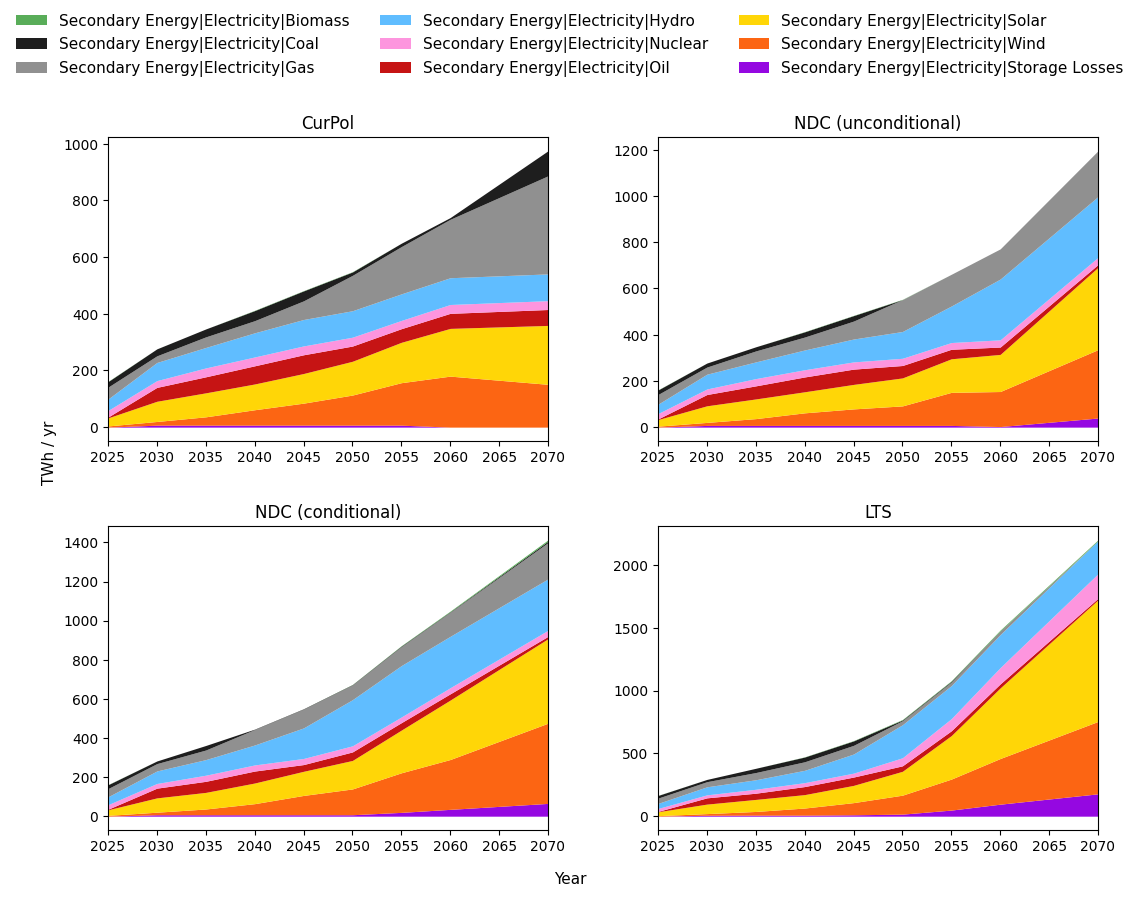

In [35]:
import matplotlib.pyplot as plt
from pyam.plotting import run_control

run_control().update({
    "color": {
        "variable": {
            "Secondary Energy|Electricity|Biomass": "#59ad59",  # bio green
            "Secondary Energy|Electricity|Coal":    "#1E1E1E",  # coal black
            "Secondary Energy|Electricity|Gas":     "#909090",  # gas grey
            "Secondary Energy|Electricity|Hydro":   "#60bdff",  # hydro blue
            "Secondary Energy|Electricity|Nuclear": "#fd95de",  # nuc pink
            "Secondary Energy|Electricity|Oil":     "#c61414",  # oil red
            "Secondary Energy|Electricity|Solar":   "#ffd607",  # solar dark yellow
            "Secondary Energy|Electricity|Wind":    "#fc6513",  # wind orange
            # optional extras so they don't take random colors:
            "Secondary Energy|Electricity|Geothermal": "#9e9e9e",
            "Secondary Energy|Electricity|Other":      "#bdbdbd",
            "Secondary Energy|Electricity|Storage Losses": "#9508e1",
        }
    }
})

# Scenarios to show (4-up)
scenarios_4 = ['CurPol', 'NDC-uncond', 'NDC-cond', 'LTS']

# Variables list you already use
vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses'
]

# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_SE:
    df = rep_all.filter(variable=var, scenario=scenarios_4).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

EJ_to_TWh = 277.778
df_all = rep_all.filter(variable=vars_keep, scenario=scenarios_4)
df_long = df_all.data.copy()           # columns: model, scenario, region, variable, unit, year, value
df_long["value"] = df_long["value"] * EJ_to_TWh
df_long["unit"] = "TWh / yr"

rep_twh = IamDataFrame(df_long)
# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 9))
axes = axes.flatten()

for ax, scen in zip(axes, scenarios_4):
    rep_twh.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    # use mapping for title if available
    ax.set_title(scenario_titles.get(scen, scen), fontsize=12, pad=6)
    ax.set_xlim(2025, 2070)
    ax.set_xticks(np.arange(2025, 2071, 5))
    ax.set_xlabel('')
    ax.set_ylabel('')


# Common labels
fig.text(0.5, 0.02, 'Year', ha='center', fontsize=11)
fig.text(0.02, 0.5, 'TWh / yr', va='center', rotation='vertical', fontsize=11)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=11, frameon=False)

plt.subplots_adjust(top=0.85, bottom=0.08, left=0.08, right=0.98, hspace=0.28, wspace=0.25)
plt.show()

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

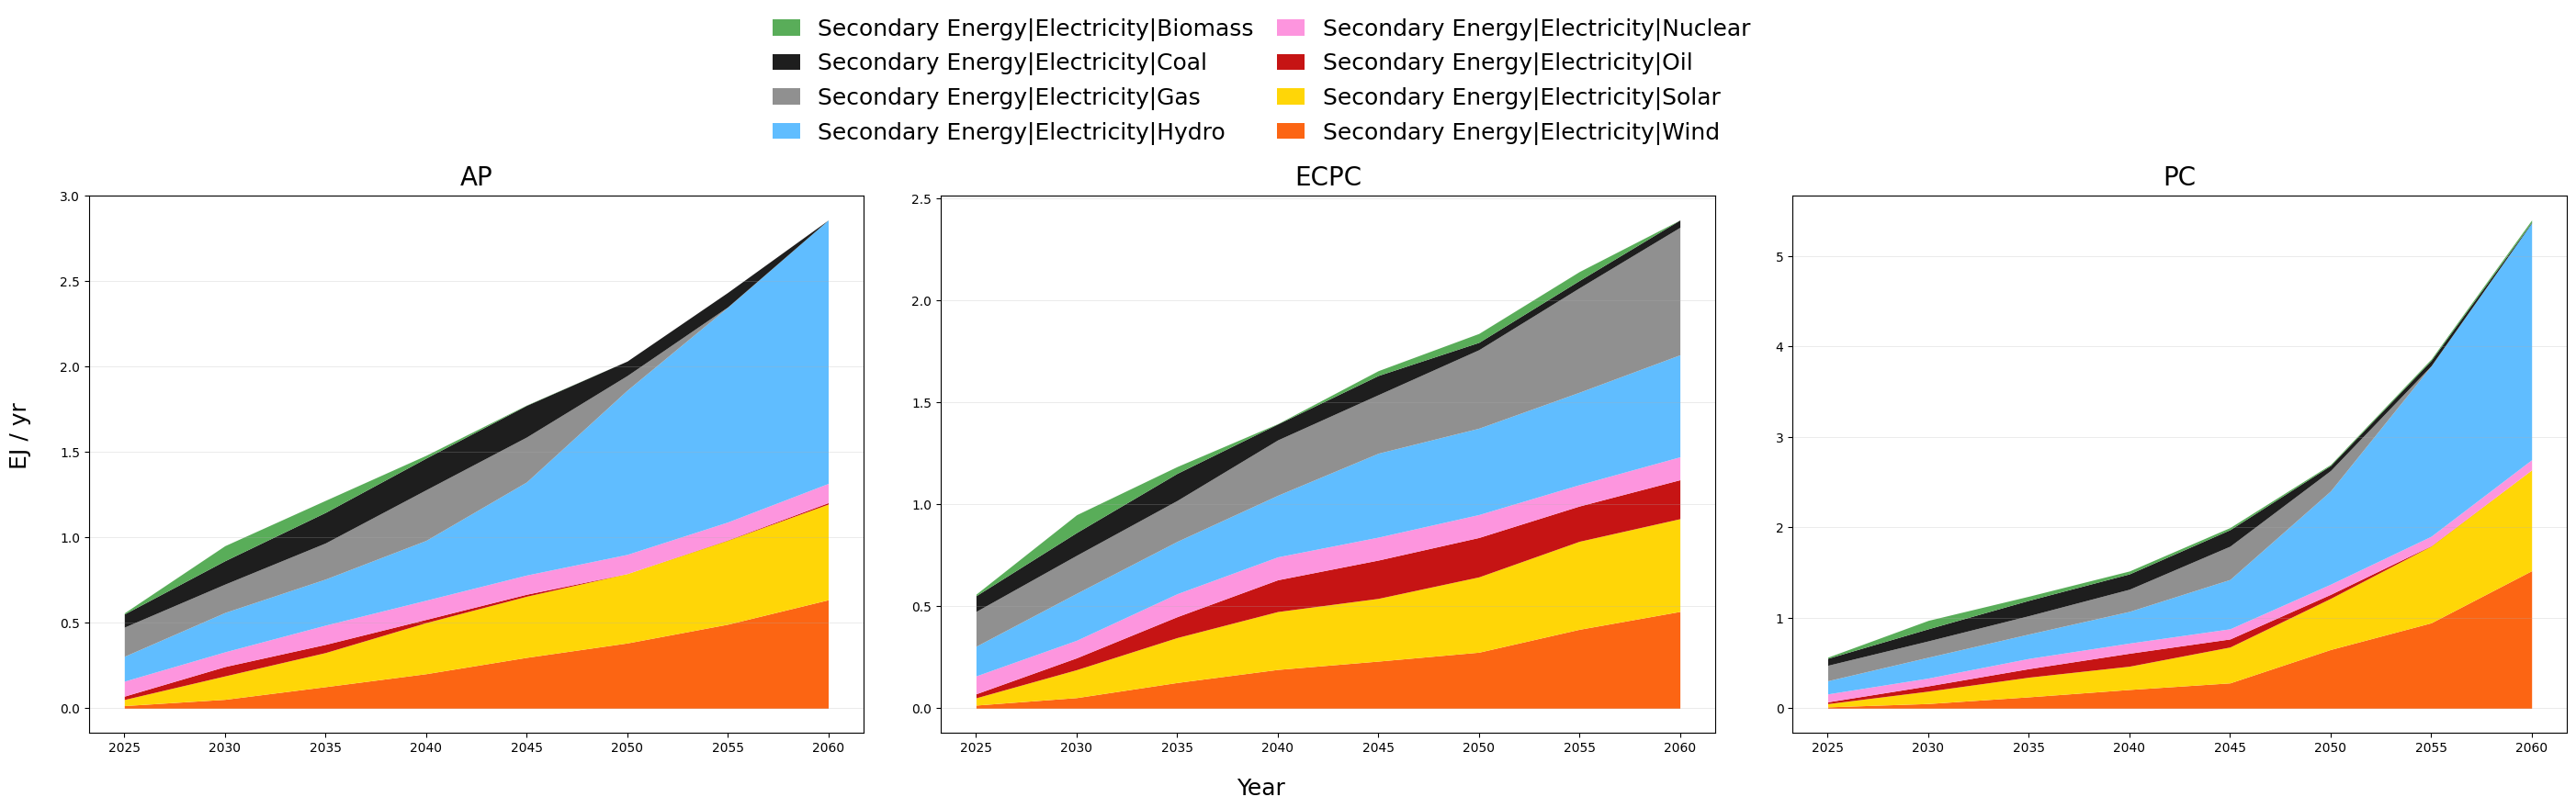

In [197]:
import matplotlib.pyplot as plt
from pyam.plotting import run_control

# --- your run_control color map stays as-is ---

scenarios_3 = ['AP', 'ECPC', 'PC']

vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses',
]

# keep variables that appear with any non-zero values across the 3 scenarios
vars_keep = []
for var in vars_SE:
    df = rep_all.filter(variable=var, scenario=scenarios_3).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# --- PLOT: 1x3, shared y, tighter spacing ---
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(29, 9))

for ax, scen in zip(axes, scenarios_3):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    ax.set_title(scen, pad=8, fontsize=20)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.25, linewidth=0.7)

# global labels
fig.supxlabel('Year', y=0.06, fontsize=18)
fig.supylabel('EJ / yr', x=0.03, fontsize=18)

# legend across the top, multi-column
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),   # lift above axes
    ncol=2,                       # adjust to your screen width
    fontsize=18,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0
)

# spacing tuned for tight look + room for legend
plt.subplots_adjust(
    left=0.06, right=0.99, bottom=0.14, top=0.79, wspace=0.10
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

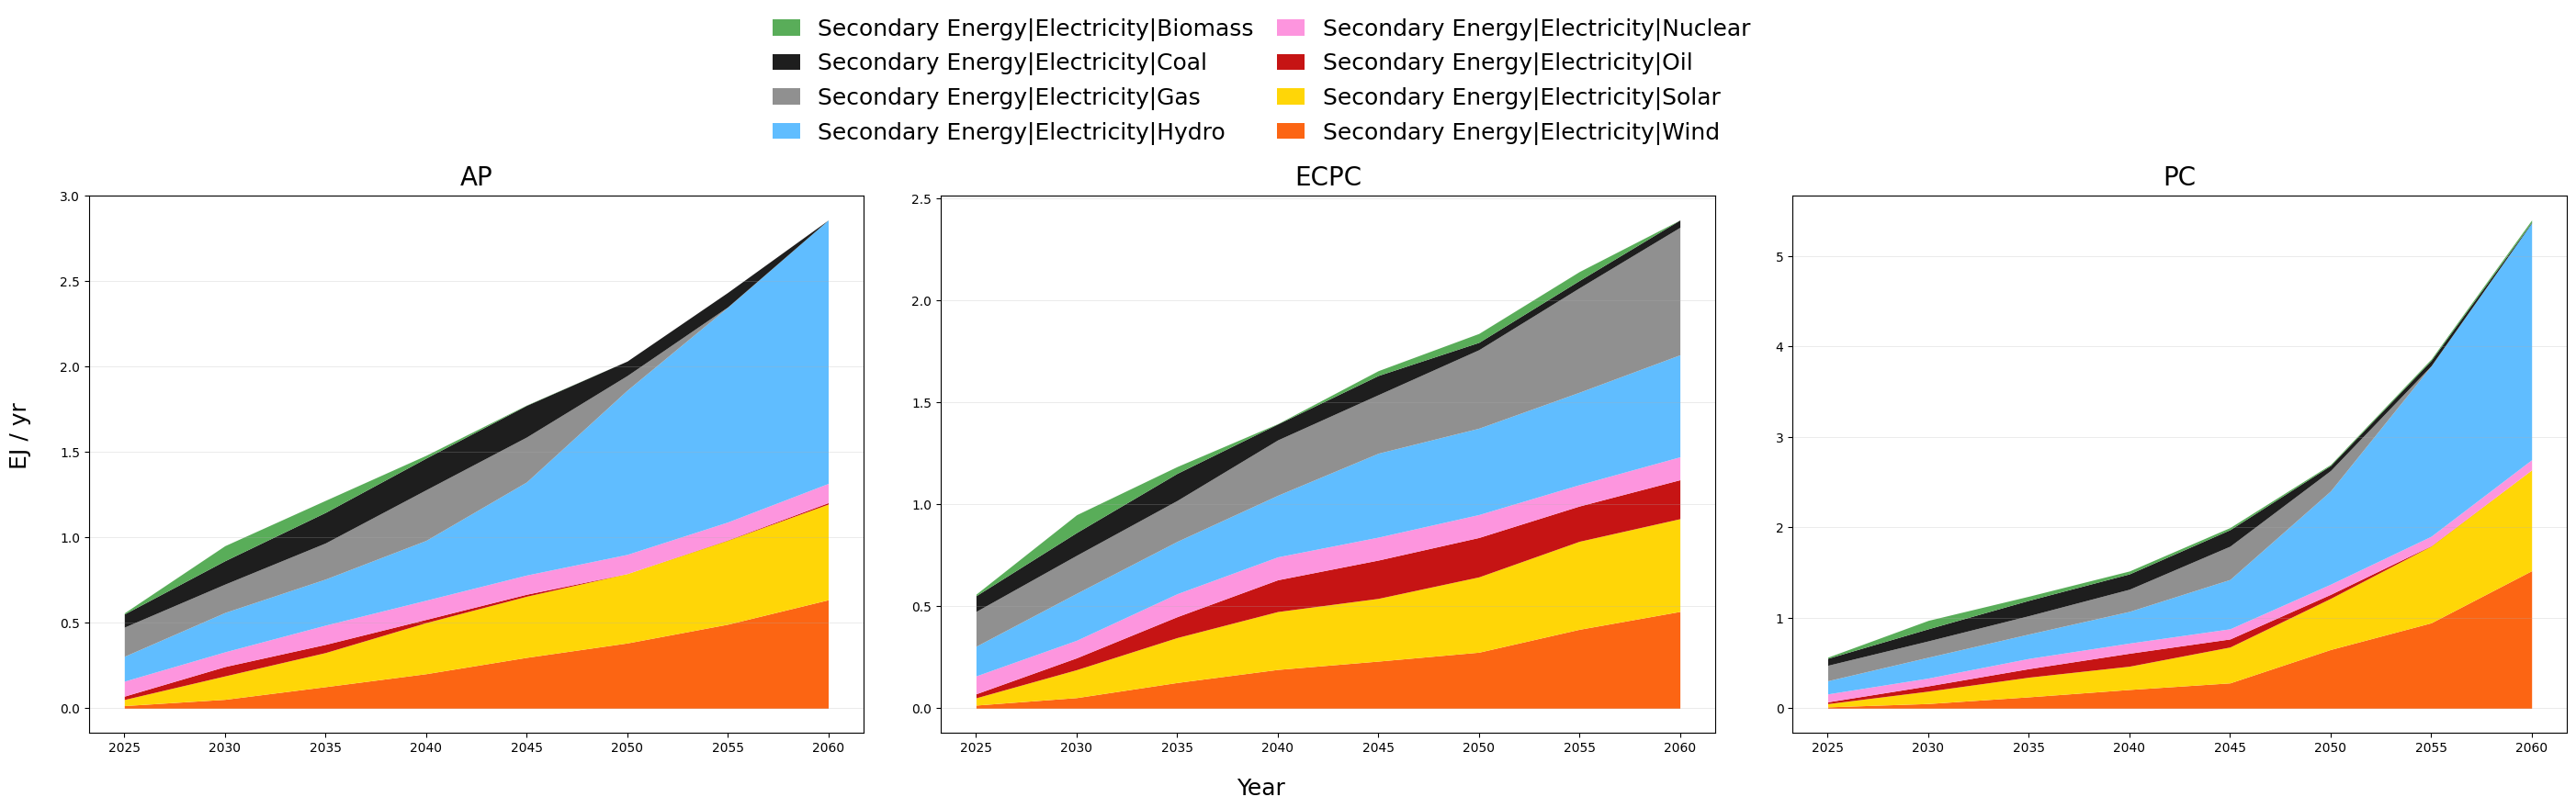

In [276]:
import matplotlib.pyplot as plt
from pyam.plotting import run_control

# --- your run_control color map stays as-is ---

scenarios_3 = ['AP', 'ECPC', 'PC']

vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses',
]

# keep variables that appear with any non-zero values across the 3 scenarios
vars_keep = []
for var in vars_SE:
    df = rep_all.filter(variable=var, scenario=scenarios_3).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# --- PLOT: 1x3, shared y, tighter spacing ---
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(29, 9))

for ax, scen in zip(axes, scenarios_3):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    ax.set_title(scen, pad=8, fontsize=20)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.25, linewidth=0.7)

# global labels
fig.supxlabel('Year', y=0.06, fontsize=18)
fig.supylabel('EJ / yr', x=0.03, fontsize=18)

# legend across the top, multi-column
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),   # lift above axes
    ncol=2,                       # adjust to your screen width
    fontsize=18,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0
)

# spacing tuned for tight look + room for legend
plt.subplots_adjust(
    left=0.06, right=0.99, bottom=0.14, top=0.79, wspace=0.10
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

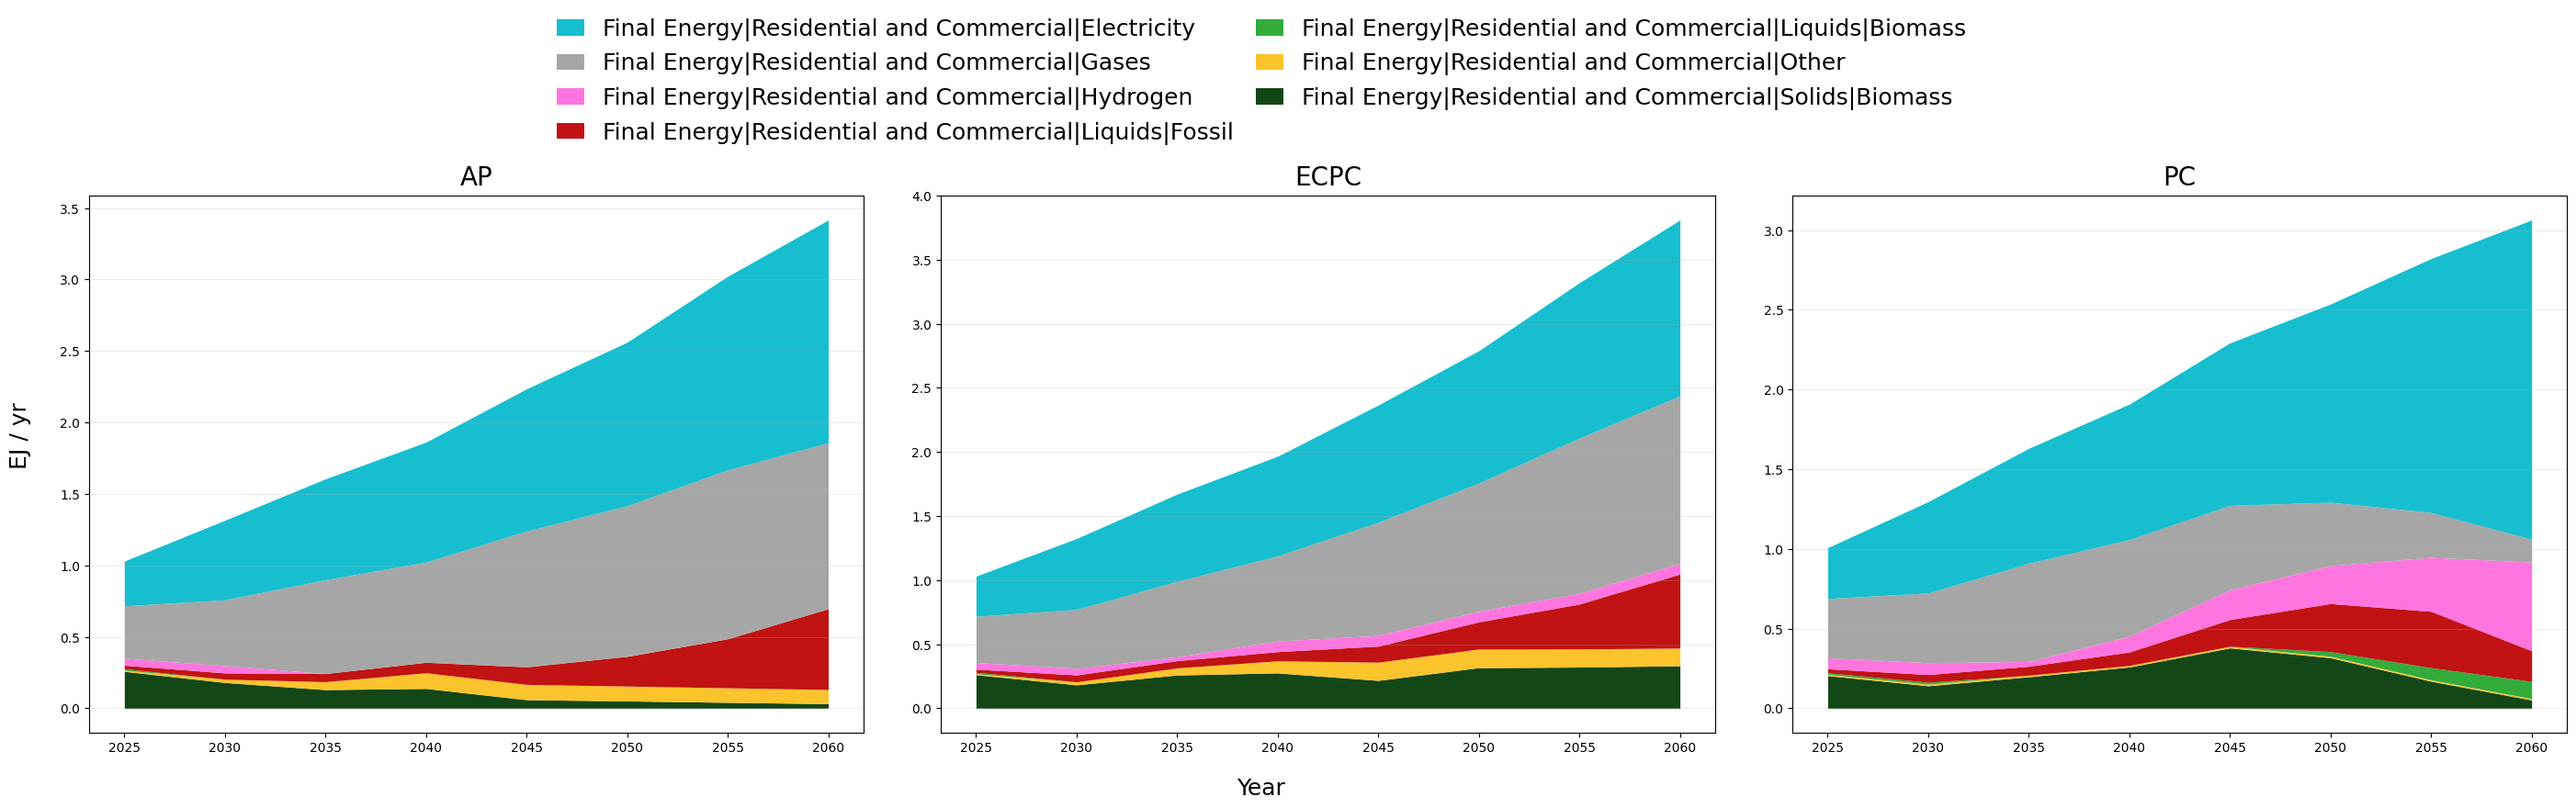

In [277]:
run_control().update({
    "color": {
        "variable": {
            "Final Energy|Residential and Commercial|Electricity": "#17becf",  
            "Final Energy|Residential and Commercial|Gases":    "#a6a6a6",  
            "Final Energy|Residential and Commercial|Hydrogen":     "#FE75E0",  
            "Final Energy|Residential and Commercial|Liquids|Fossil":   "#C11313",  
            "Final Energy|Residential and Commercial|Liquids|Biomass": "#33AC3B", 
            "Final Energy|Residential and Commercial|Other":     "#fbc42c",  
            "Final Energy|Residential and Commercial|Solids|Fossil":   "#0E0E0E",  
            "Final Energy|Residential and Commercial|Solids|Biomass":    "#144717", 
        }
    }
})

# Scenarios to show (4-up)
scenarios_3 = ["AP", "ECPC", "PC"]

# Variables list you already use
vars_FE = [
    "Final Energy|Residential and Commercial|Electricity",
    "Final Energy|Residential and Commercial|Gases",
    "Final Energy|Residential and Commercial|Hydrogen",
    "Final Energy|Residential and Commercial|Liquids|Fossil",
    "Final Energy|Residential and Commercial|Liquids|Biomass",
    "Final Energy|Residential and Commercial|Other",
    "Final Energy|Residential and Commercial|Solids|Fossil",
    "Final Energy|Residential and Commercial|Solids|Biomass",
]

# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_FE:
    df = rep_all.filter(variable=var, scenario=scenarios_3).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(29, 9))

for ax, scen in zip(axes, scenarios_3):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    ax.set_title(scen, pad=8, fontsize=20)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.25, linewidth=0.7)

# global labels
fig.supxlabel('Year', y=0.06, fontsize=18)
fig.supylabel('EJ / yr', x=0.03, fontsize=18)

# legend across the top, multi-column
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),   # lift above axes
    ncol=2,                       # adjust to your screen width
    fontsize=18,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0
)

# spacing tuned for tight look + room for legend
plt.subplots_adjust(
    left=0.06, right=0.99, bottom=0.14, top=0.79, wspace=0.10
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

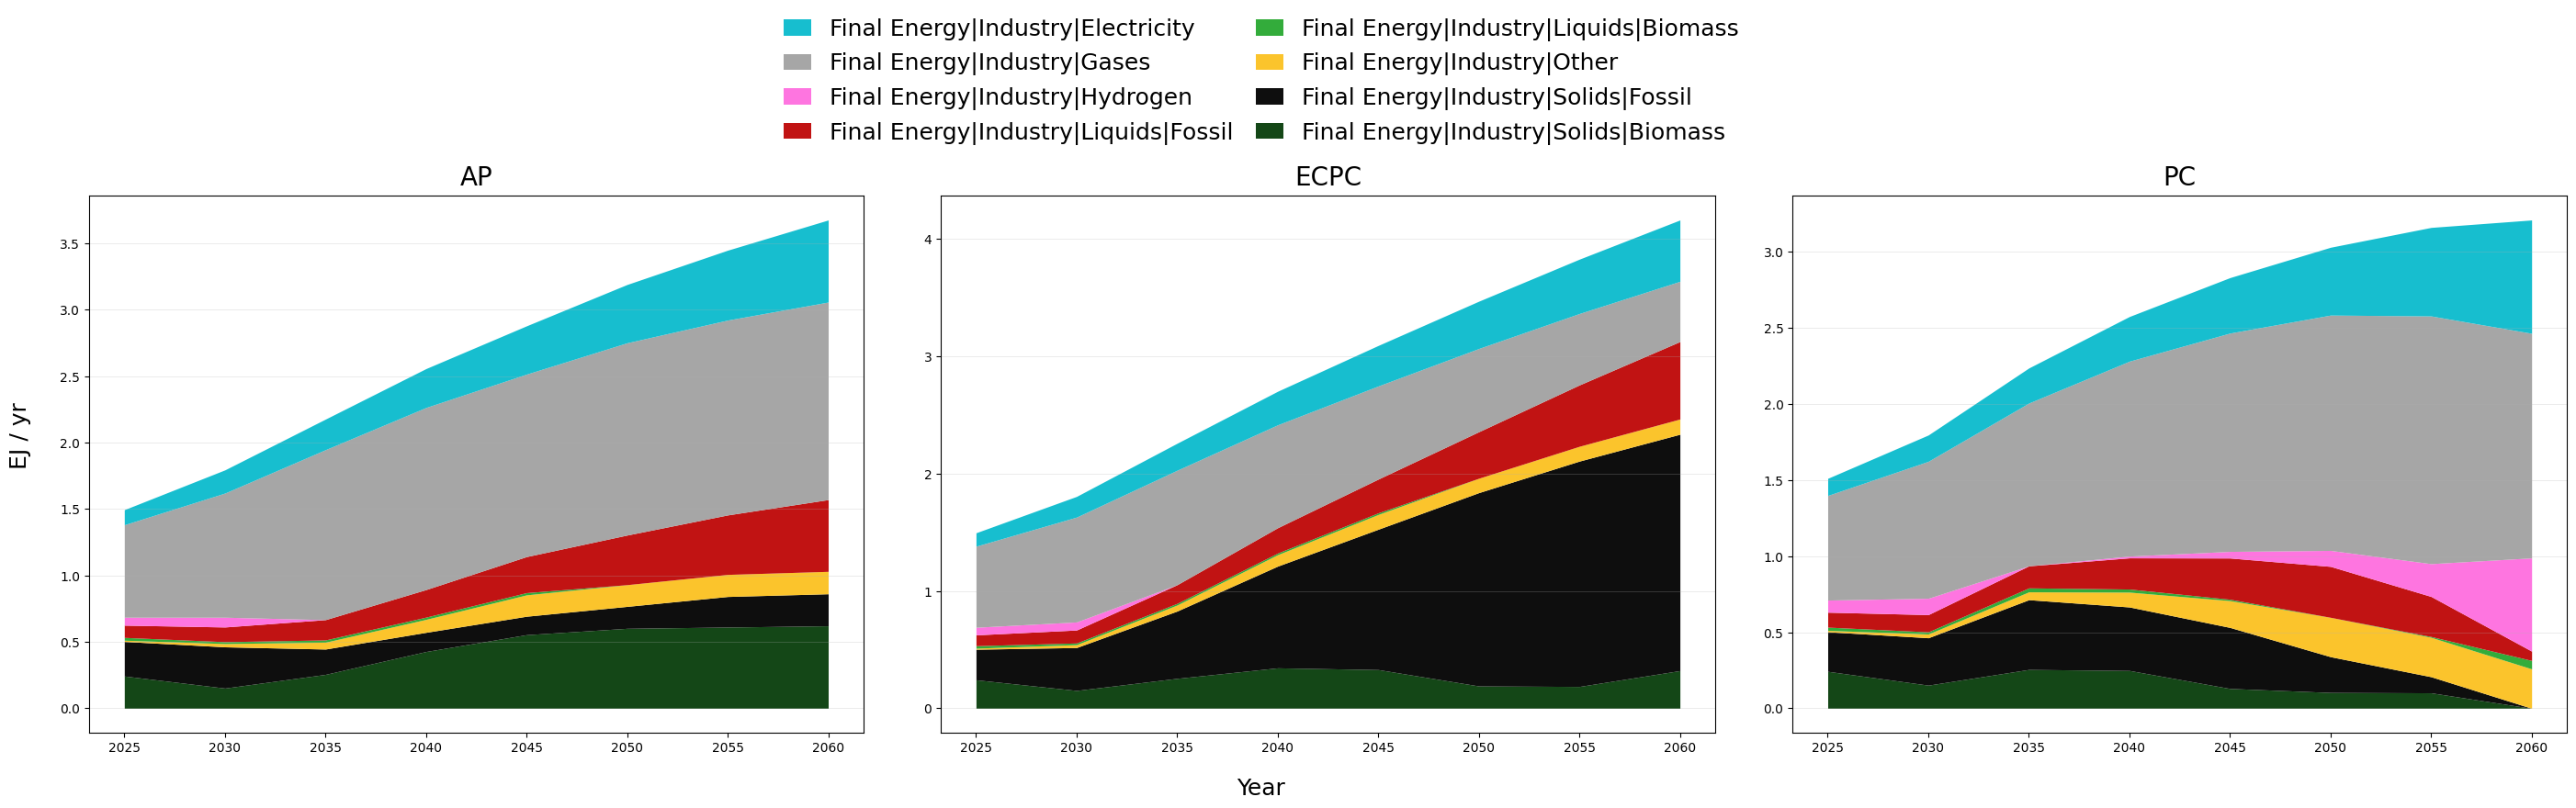

In [278]:
run_control().update({
    "color": {
        "variable": {
            "Final Energy|Industry|Electricity": "#17becf",  
            "Final Energy|Industry|Gases":    "#a6a6a6",  
            "Final Energy|Industry|Hydrogen":     "#FE75E0",  
            "Final Energy|Industry|Liquids|Fossil":   "#C11313",  
            "Final Energy|Industry|Liquids|Biomass": "#33AC3B", 
            "Final Energy|Industry|Other":     "#fbc42c",  
            "Final Energy|Industry|Solids|Fossil":   "#0E0E0E",  
            "Final Energy|Industry|Solids|Biomass":    "#144717", 
        }
    }
})

# Scenarios to show (4-up)
scenarios_3 = ["AP", "ECPC", "PC"]

# Variables list you already use
vars_FE = [
    "Final Energy|Industry|Electricity",
    "Final Energy|Industry|Gases",
    # "Final Energy|Industry|Heat",
    "Final Energy|Industry|Hydrogen",
    "Final Energy|Industry|Liquids|Fossil",
    "Final Energy|Industry|Liquids|Biomass",
    "Final Energy|Industry|Other",
    "Final Energy|Industry|Solids|Fossil",
    "Final Energy|Industry|Solids|Biomass",
]

# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_FE:
    df = rep_all.filter(variable=var, scenario=scenarios_3).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(29, 9))

for ax, scen in zip(axes, scenarios_3):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    ax.set_title(scen, pad=8, fontsize=20)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(axis='y', alpha=0.25, linewidth=0.7)

# global labels
fig.supxlabel('Year', y=0.06, fontsize=18)
fig.supylabel('EJ / yr', x=0.03, fontsize=18)

# legend across the top, multi-column
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),   # lift above axes
    ncol=2,                       # adjust to your screen width
    fontsize=18,
    frameon=False,
    handlelength=1.2,
    columnspacing=1.0
)

# spacing tuned for tight look + room for legend
plt.subplots_adjust(
    left=0.06, right=0.99, bottom=0.14, top=0.79, wspace=0.10
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

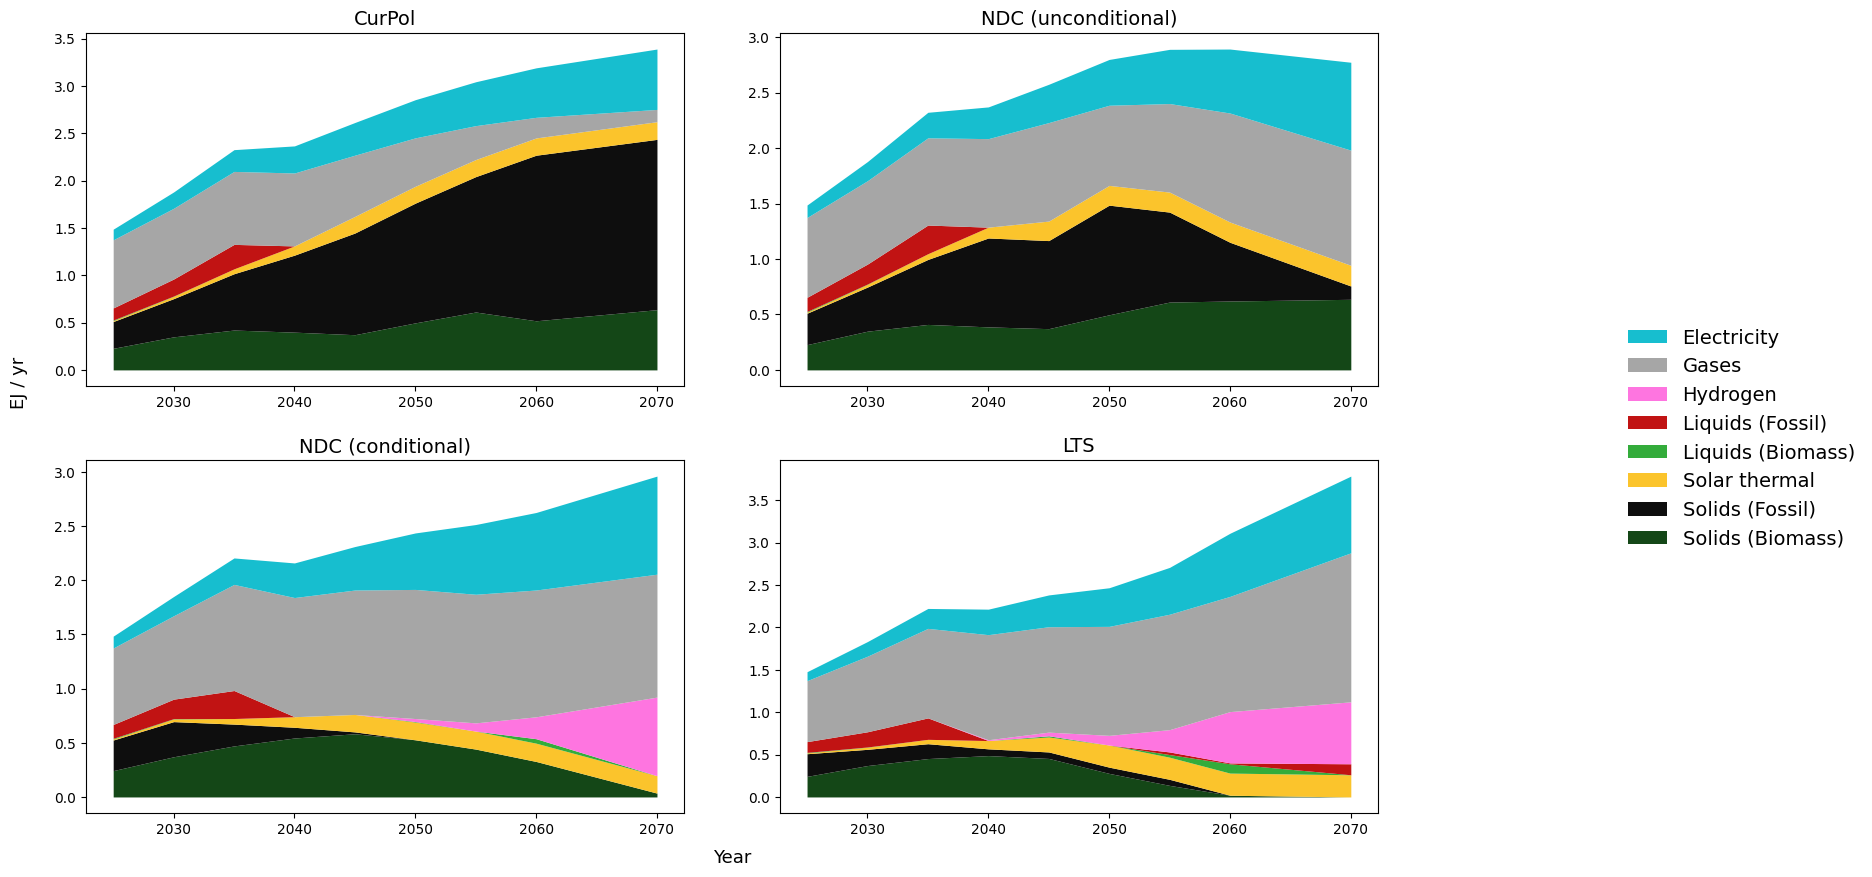

In [41]:
run_control().update({
    "color": {
        "variable": {
            "Final Energy|Industry|Electricity": "#17becf",  
            "Final Energy|Industry|Gases":    "#a6a6a6",  
            "Final Energy|Industry|Hydrogen":     "#FE75E0",  
            "Final Energy|Industry|Liquids|Fossil":   "#C11313",  
            "Final Energy|Industry|Liquids|Biomass": "#33AC3B", 
            "Final Energy|Industry|Other":     "#fbc42c",  
            "Final Energy|Industry|Solids|Fossil":   "#0E0E0E",  
            "Final Energy|Industry|Solids|Biomass":    "#144717", 
        }
    }
})


# Variables list you already use
vars_FE = [
    "Final Energy|Industry|Electricity",
    "Final Energy|Industry|Gases",
    # "Final Energy|Industry|Heat",
    "Final Energy|Industry|Hydrogen",
    "Final Energy|Industry|Liquids|Fossil",
    "Final Energy|Industry|Liquids|Biomass",
    "Final Energy|Industry|Other",
    "Final Energy|Industry|Solids|Fossil",
    "Final Energy|Industry|Solids|Biomass",
]
# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_FE:
    df = rep_all.filter(variable=var).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(19, 10))
axes = axes.flatten()

for ax, scen in zip(axes, scenarios_4):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    # use mapping for title if available
    ax.set_title(scenario_titles.get(scen, scen), fontsize=14, pad=6)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Common labels
fig.text(0.40, 0.02, 'Year', ha='center', fontsize=13)
fig.text(0.02, 0.5, 'EJ / yr', va='center', rotation='vertical', fontsize=13)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

def nice_label(full):
    parts = full.split("|")              # e.g. "Final Energy|Industry|Liquids|Fossil"
    tail = parts[2:]                     # after "Final Energy|Industry" -> ["Liquids","Fossil"]
    if tail[0] == "Other":
        return "Solar thermal"
    if len(tail) == 1:
        return tail[0]                   # Electricity, Gases, Hydrogen
    return f"{tail[0]} ({tail[1]})"      # Liquids (Fossil), Solids (Biomass), ...

labels_simple = [nice_label(l) for l in labels]

fig.legend(
    handles, labels_simple,
    loc='center right',
    fontsize=14,
    frameon=False
)

plt.subplots_adjust(top=0.85, bottom=0.07, left=0.06, right=0.74, hspace=0.21, wspace=0.16)
plt.show()

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

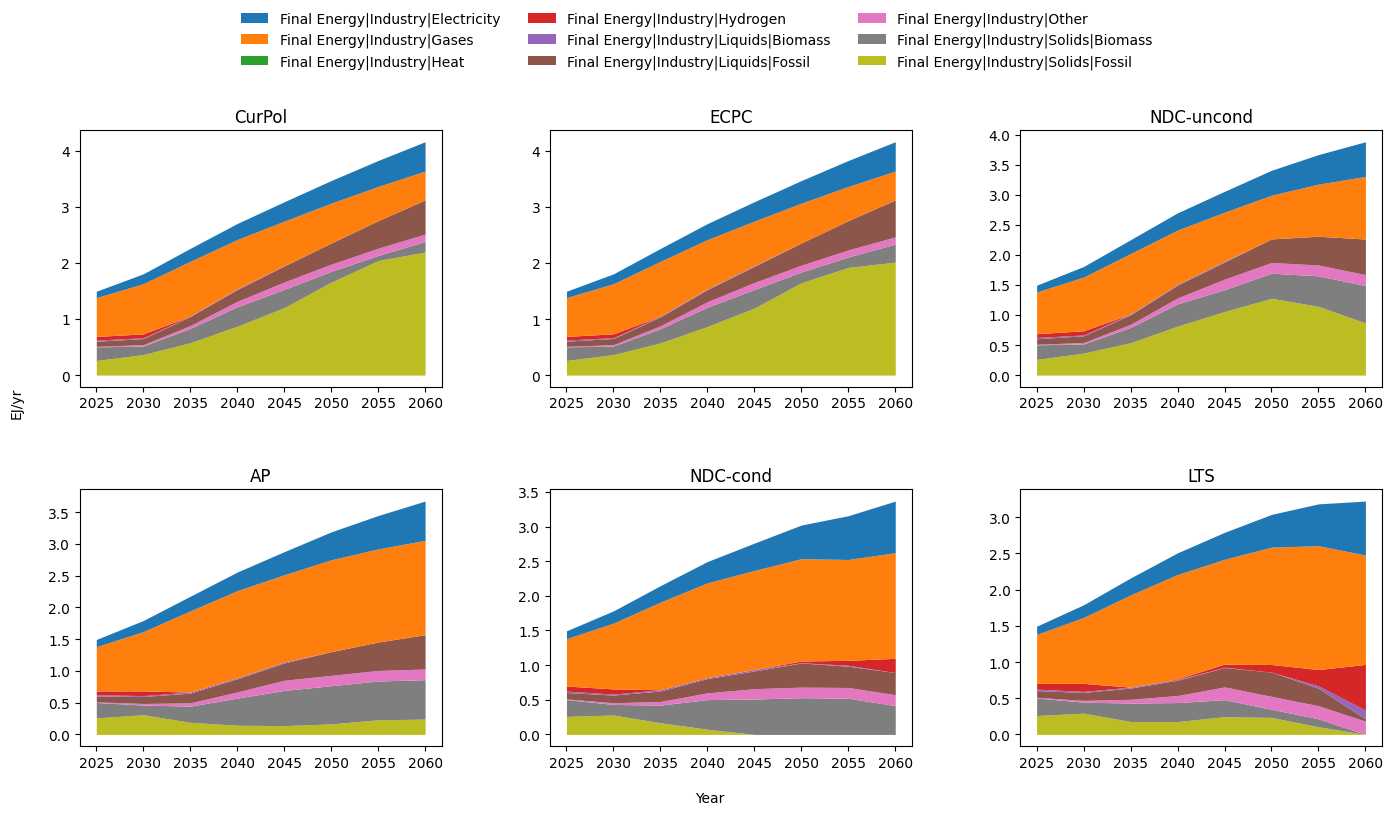

In [149]:
import matplotlib.pyplot as plt

# Scenarios you want in fixed order
scenarios = ['CurPol', 'ECPC', "NDC-uncond", 'AP', 'NDC-cond', 'LTS']

# Variables to include in each stackplot
vars_FE = [
    "Final Energy|Industry|Electricity",
    "Final Energy|Industry|Gases",
    "Final Energy|Industry|Heat",
    "Final Energy|Industry|Hydrogen",
    "Final Energy|Industry|Liquids|Fossil",
    "Final Energy|Industry|Liquids|Biomass",
    "Final Energy|Industry|Other",
    "Final Energy|Industry|Solids|Fossil",
    "Final Energy|Industry|Solids|Biomass",

]

# Setup subplots
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    figsize=(14, 8)
)

axes = axes.flatten()

# Plot each scenario in its own subplot
for ax, scen in zip(axes, scenarios):
    rep_all.filter(variable=vars_FE, scenario=scen).plot.stack(
        ax=ax,
        legend=False
    )
    ax.set_title(scen)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Add common axis labels
fig.text(0.5, 0.0001, 'Year', ha='center', fontsize=10)
fig.text(0.0001, 0.5, 'EJ/yr', va='center', rotation='vertical', fontsize=10)

# Add legend from one of the axes
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=3,
    fontsize=10,
    frameon=False
)

plt.subplots_adjust(
    top=0.84,  # more vertical space for legend
    bottom=0.07,
    left=0.05,
    right=0.98,
    hspace=0.4,
    wspace=0.3
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

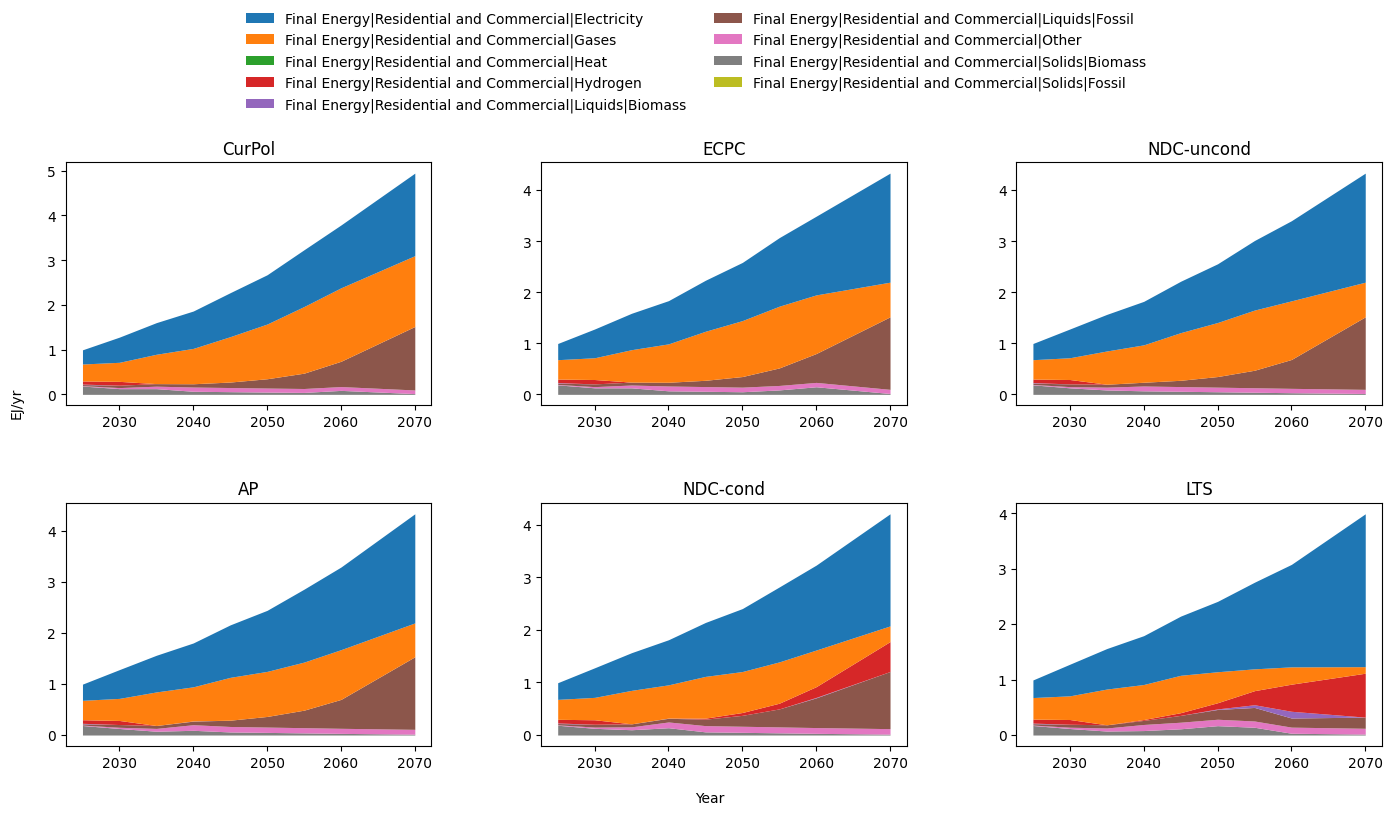

In [13]:
import matplotlib.pyplot as plt

# Scenarios you want in fixed order
scenarios = ['CurPol', 'ECPC', "NDC-uncond", 'AP', 'NDC-cond', 'LTS']

# Variables to include in each stackplot
vars_SE = [
    "Final Energy|Residential and Commercial|Electricity",
    "Final Energy|Residential and Commercial|Gases",
    "Final Energy|Residential and Commercial|Heat",
    "Final Energy|Residential and Commercial|Hydrogen",
    "Final Energy|Residential and Commercial|Liquids|Fossil",
    "Final Energy|Residential and Commercial|Liquids|Biomass",
    "Final Energy|Residential and Commercial|Other",
    "Final Energy|Residential and Commercial|Solids|Fossil",
    "Final Energy|Residential and Commercial|Solids|Biomass",
]

# Setup subplots
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    figsize=(14, 8)
)

axes = axes.flatten()

# Plot each scenario in its own subplot
for ax, scen in zip(axes, scenarios):
    rep_all.filter(variable=vars_SE, scenario=scen).plot.stack(
        ax=ax,
        legend=False
    )
    ax.set_title(scen)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Add common axis labels
fig.text(0.5, 0.0001, 'Year', ha='center', fontsize=10)
fig.text(0.0001, 0.5, 'EJ/yr', va='center', rotation='vertical', fontsize=10)

# Add legend from one of the axes
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=2,
    fontsize=10,
    frameon=False
)

plt.subplots_adjust(
    top=0.80,  # more vertical space for legend
    bottom=0.07,
    left=0.04,
    right=0.98,
    hspace=0.4,
    wspace=0.3
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

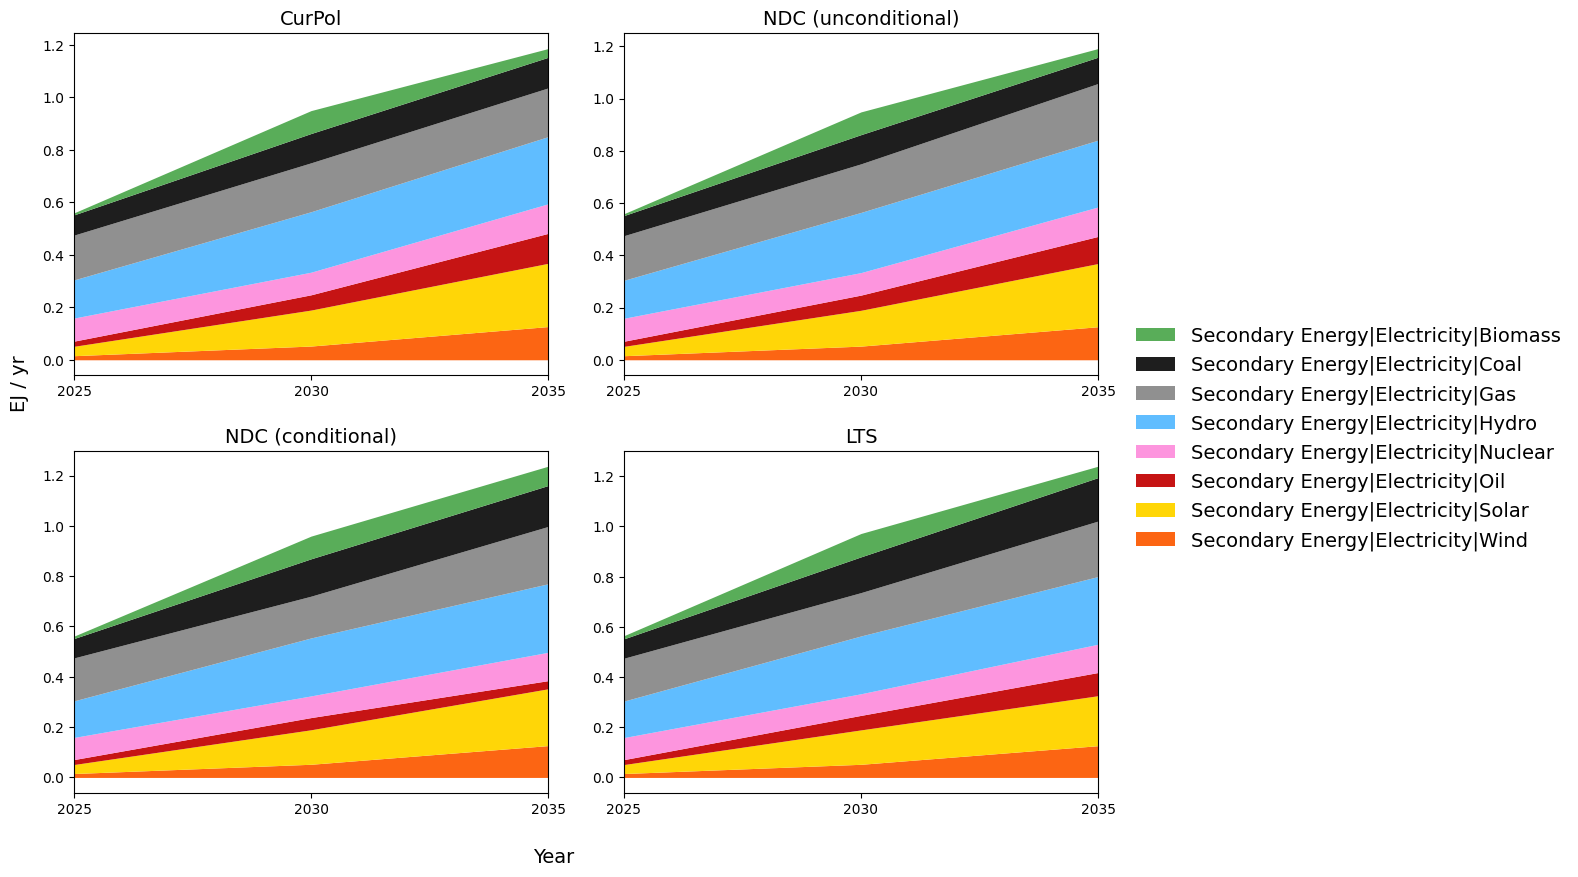

In [16]:
import matplotlib.pyplot as plt
from pyam.plotting import run_control

run_control().update({
    "color": {
        "variable": {
            "Secondary Energy|Electricity|Biomass": "#59ad59",  # bio green
            "Secondary Energy|Electricity|Coal":    "#1E1E1E",  # coal black
            "Secondary Energy|Electricity|Gas":     "#909090",  # gas grey
            "Secondary Energy|Electricity|Hydro":   "#60bdff",  # hydro blue
            "Secondary Energy|Electricity|Nuclear": "#fd95de",  # nuc pink
            "Secondary Energy|Electricity|Oil":     "#c61414",  # oil red
            "Secondary Energy|Electricity|Solar":   "#ffd607",  # solar dark yellow
            "Secondary Energy|Electricity|Wind":    "#fc6513",  # wind orange
            # optional extras so they don't take random colors:
            "Secondary Energy|Electricity|Geothermal": "#9e9e9e",
            "Secondary Energy|Electricity|Other":      "#bdbdbd",
            "Secondary Energy|Electricity|Storage Losses": "#9508e1",
        }
    }
})

# Scenarios to show (4-up)
scenarios_4 = ['CurPol', 'NDC-uncond', 'NDC-cond', 'LTS']

# Variables list you already use
vars_SE = [
    'Secondary Energy|Electricity|Biomass',
    'Secondary Energy|Electricity|Coal',
    'Secondary Energy|Electricity|Gas',
    'Secondary Energy|Electricity|Geothermal',
    'Secondary Energy|Electricity|Hydro',
    'Secondary Energy|Electricity|Nuclear',
    'Secondary Energy|Electricity|Oil',
    'Secondary Energy|Electricity|Other',
    'Secondary Energy|Electricity|Solar',
    'Secondary Energy|Electricity|Wind',
    'Secondary Energy|Electricity|Storage Losses'
]

# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_SE:
    df = rep_all.filter(variable=var, scenario=scenarios_4).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for ax, scen in zip(axes, scenarios_4):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    # use mapping for title if available
    ax.set_title(scenario_titles.get(scen, scen), fontsize=14, pad=6)
    ax.set_xlim(2025, 2035)
    ax.set_xticks(np.arange(2025, 2036, 5))
    ax.set_xlabel('')
    ax.set_ylabel('')

# Common labels
fig.text(0.36, 0.02, 'Year', ha='center', fontsize=14)
fig.text(0.02, 0.5, 'EJ / yr', va='center', rotation='vertical', fontsize=14)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', fontsize=14, frameon=False)

plt.subplots_adjust(top=0.85, bottom=0.09, left=0.06, right=0.70, hspace=0.22, wspace=0.16)
plt.show()

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

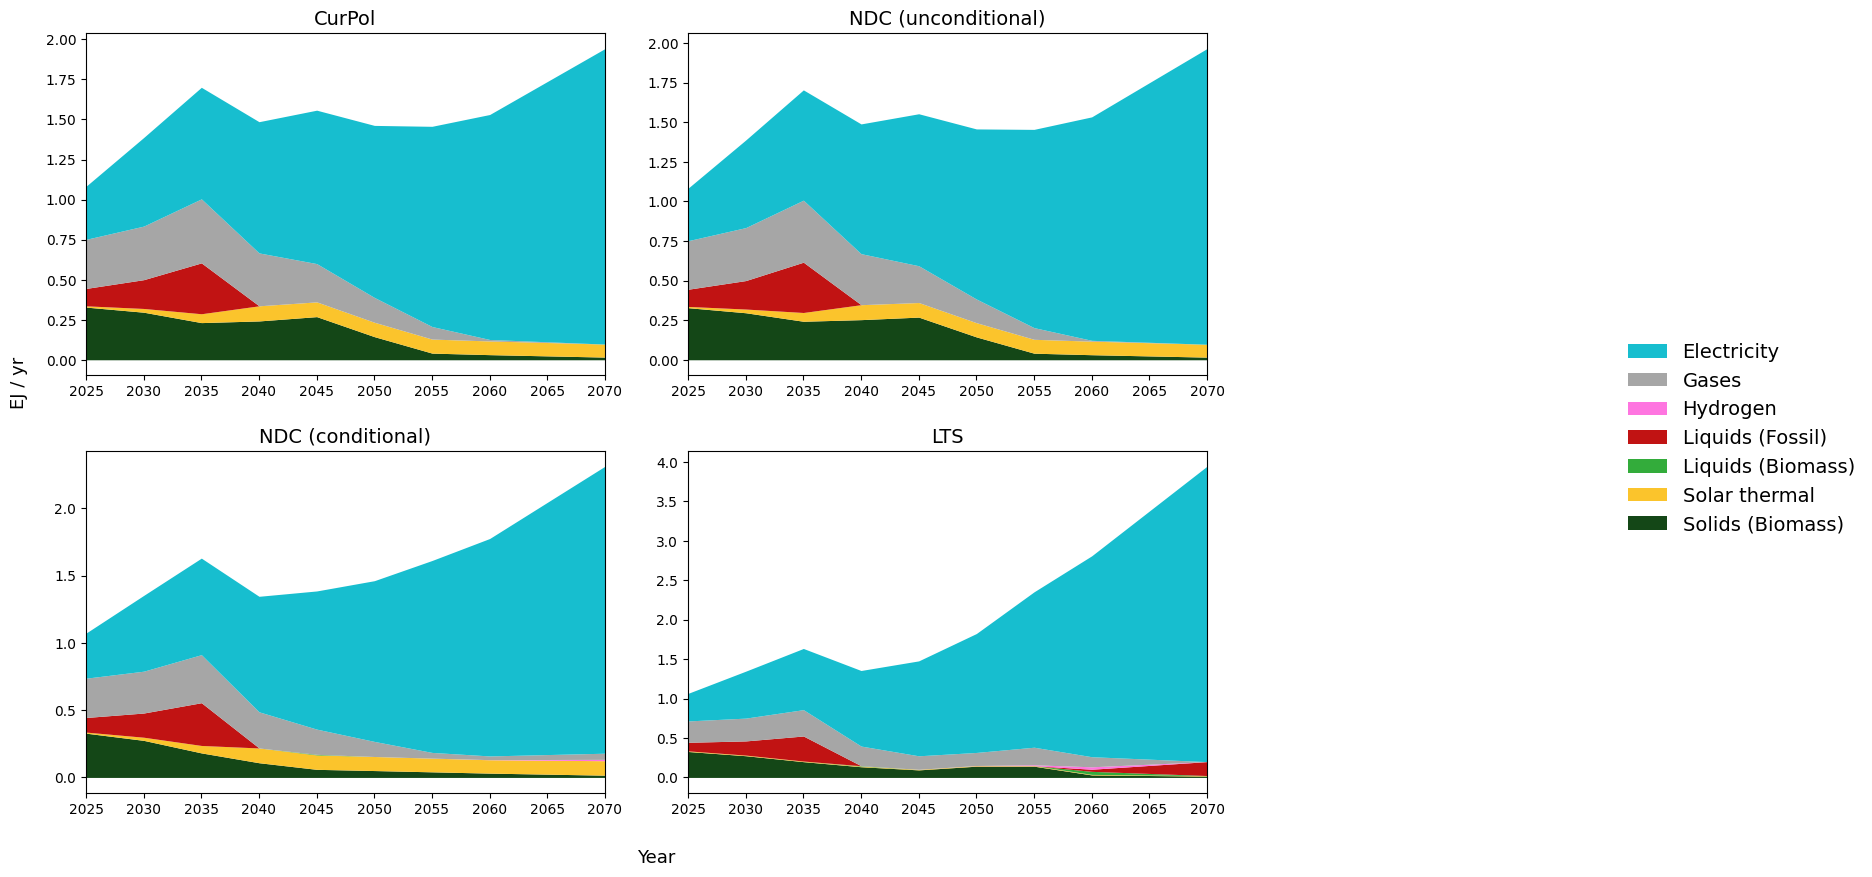

In [43]:
run_control().update({
    "color": {
        "variable": {
            "Final Energy|Residential and Commercial|Electricity": "#17becf",  
            "Final Energy|Residential and Commercial|Gases":    "#a6a6a6",  
            "Final Energy|Residential and Commercial|Hydrogen":     "#FE75E0",  
            "Final Energy|Residential and Commercial|Liquids|Fossil":   "#C11313",  
            "Final Energy|Residential and Commercial|Liquids|Biomass": "#33AC3B", 
            "Final Energy|Residential and Commercial|Other":     "#fbc42c",  
            "Final Energy|Residential and Commercial|Solids|Fossil":   "#0E0E0E",  
            "Final Energy|Residential and Commercial|Solids|Biomass":    "#144717", 
        }
    }
})

# Scenarios to show (4-up)
scenarios_4 = ['CurPol', 'NDC-uncond', 'NDC-cond', 'LTS']

# Variables list you already use
vars_FE = [
    "Final Energy|Residential and Commercial|Electricity",
    "Final Energy|Residential and Commercial|Gases",
    "Final Energy|Residential and Commercial|Hydrogen",
    "Final Energy|Residential and Commercial|Liquids|Fossil",
    "Final Energy|Residential and Commercial|Liquids|Biomass",
    "Final Energy|Residential and Commercial|Other",
    "Final Energy|Residential and Commercial|Solids|Fossil",
    "Final Energy|Residential and Commercial|Solids|Biomass",
]

# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_FE:
    df = rep_all.filter(variable=var, scenario=scenarios_4).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(19, 10))
axes = axes.flatten()

for ax, scen in zip(axes, scenarios_4):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    # use mapping for title if available
    ax.set_title(scenario_titles.get(scen, scen), fontsize=14, pad=6)
    ax.set_xlim(2025, 2070)
    ax.set_xticks(np.arange(2025, 2071, 5))
    ax.set_xlabel('')
    ax.set_ylabel('')

# Common labels
fig.text(0.36, 0.02, 'Year', ha='center', fontsize=13)
fig.text(0.02, 0.5, 'EJ / yr', va='center', rotation='vertical', fontsize=13)

# Shared legend
# --- Shared legend with simplified labels ---
handles, labels = axes[0].get_legend_handles_labels()

def simplify(full):
    # e.g. "Final Energy|Residential and Commercial|Liquids|Fossil"
    parts = full.split("|")
    tail = parts[2:]  # drop "Final Energy|Residential and Commercial"
    if not tail:
        return full
    if tail[0] == "Other":
        return "Solar thermal"
    if len(tail) == 1:
        return tail[0]  # Electricity, Gases, Hydrogen
    # For things like Liquids|Fossil, Solids|Biomass
    return f"{tail[0]} ({tail[1]})"

labels_simple = [simplify(l) for l in labels]

fig.legend(
    handles, labels_simple,
    loc='center right',
    fontsize=14,
    frameon=False
)

plt.subplots_adjust(top=0.85, bottom=0.09, left=0.06, right=0.65, hspace=0.22, wspace=0.16)
plt.show()

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

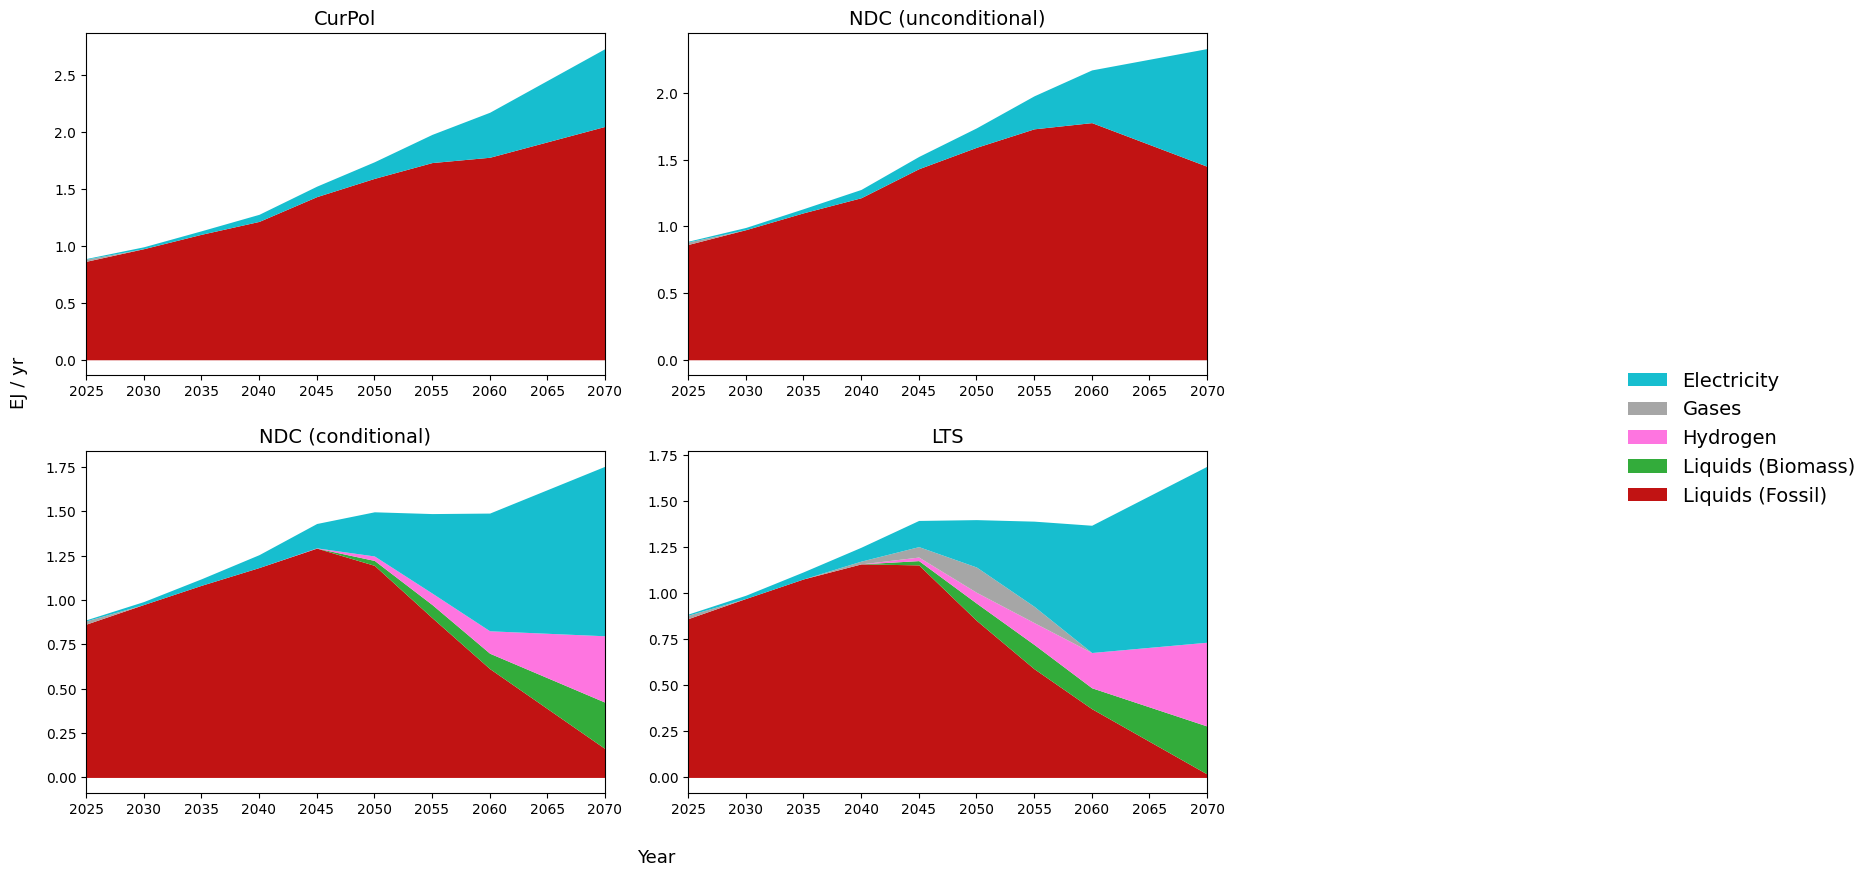

In [51]:
run_control().update({
    "color": {
        "variable": {
            "Final Energy|Transportation|Electricity": "#17becf",  
            "Final Energy|Transportation|Gases":    "#a6a6a6",  
            "Final Energy|Transportation|Hydrogen":     "#FE75E0",  
            "Final Energy|Transportation|Liquids|Fossil":   "#C11313",  
            "Final Energy|Transportation|Liquids|Biomass": "#33AC3B", 
            "Final Energy|Transportation|Other":     "#fbc42c",  
            }
    }
})

# Scenarios to show (4-up)
scenarios_4 = ['CurPol', 'NDC-uncond', 'NDC-cond', 'LTS']

# Variables list you already use
vars_FE = [
    "Final Energy|Transportation|Electricity",
    "Final Energy|Transportation|Gases",
    "Final Energy|Transportation|Hydrogen",
    "Final Energy|Transportation|Liquids|Biomass",
    "Final Energy|Transportation|Other",
    "Final Energy|Transportation|Liquids|Fossil",
]

# Keep only variables that are non-zero in *any* of the four scenarios
vars_keep = []
for var in vars_FE:
    df = rep_all.filter(variable=var, scenario=scenarios_4).timeseries()
    if len(df) and not (df == 0).all(axis=None):
        vars_keep.append(var)

# ---- Plot: 2x2 subplots, shared y for comparability ----
scenario_titles = {
    "NDC-uncond": "NDC (unconditional)",
    "NDC-cond": "NDC (conditional)",
}

# ---- Plot: 2x2 subplots, shared y for comparability ----
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(19, 10))
axes = axes.flatten()

for ax, scen in zip(axes, scenarios_4):
    rep_all.filter(variable=vars_keep, scenario=scen).plot.stack(
        ax=ax,
        order=vars_keep,
        legend=False
    )
    # use mapping for title if available
    ax.set_title(scenario_titles.get(scen, scen), fontsize=14, pad=6)
    ax.set_xlim(2025, 2070)
    ax.set_xticks(np.arange(2025, 2071, 5))
    ax.set_xlabel('')
    ax.set_ylabel('')

# Common labels
fig.text(0.36, 0.02, 'Year', ha='center', fontsize=13)
fig.text(0.02, 0.5, 'EJ / yr', va='center', rotation='vertical', fontsize=13)

# Shared legend
# --- Shared legend with simplified labels ---
handles, labels = axes[0].get_legend_handles_labels()

def simplify(full):
    # e.g. "Final Energy|Residential and Commercial|Liquids|Fossil"
    parts = full.split("|")
    tail = parts[2:]  # drop "Final Energy|Residential and Commercial"
    if not tail:
        return full
    if tail[0] == "Other":
        return "Solar thermal"
    if len(tail) == 1:
        return tail[0]  # Electricity, Gases, Hydrogen
    # For things like Liquids|Fossil, Solids|Biomass
    return f"{tail[0]} ({tail[1]})"

labels_simple = [simplify(l) for l in labels]

fig.legend(
    handles, labels_simple,
    loc='center right',
    fontsize=14,
    frameon=False
)

plt.subplots_adjust(top=0.85, bottom=0.09, left=0.06, right=0.65, hspace=0.22, wspace=0.16)
plt.show()

d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empt

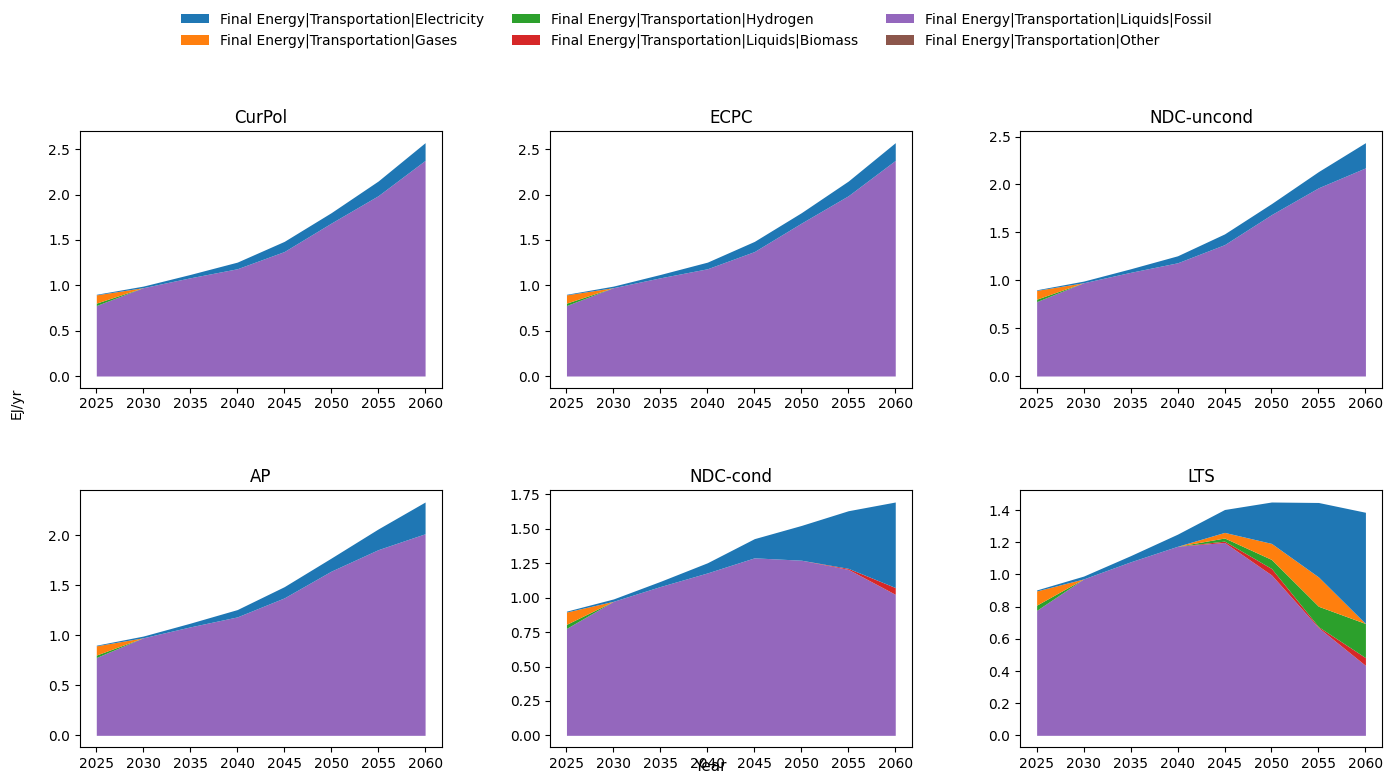

In [235]:
import matplotlib.pyplot as plt

# Scenarios you want in fixed order
scenarios = ['CurPol', 'ECPC', "NDC-uncond", 'AP', 'NDC-cond', 'LTS']

# Variables to include in each stackplot
vars_FE = [
    "Final Energy|Transportation|Electricity",
    "Final Energy|Transportation|Gases",
    "Final Energy|Transportation|Hydrogen",
    "Final Energy|Transportation|Liquids|Biomass",
    "Final Energy|Transportation|Other",
    "Final Energy|Transportation|Liquids|Fossil",
]

# Setup subplots
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    figsize=(14, 8)
)

axes = axes.flatten()

# Plot each scenario in its own subplot
for ax, scen in zip(axes, scenarios):
    rep_all.filter(variable=vars_FE, scenario=scen).plot.stack(
        ax=ax,
        legend=False
    )
    ax.set_title(scen)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Add common axis labels
fig.text(0.5, 0.04, 'Year', ha='center', fontsize=11)
fig.text(0.0001, 0.5, 'EJ/yr', va='center', rotation='vertical', fontsize=10)

# Add legend from one of the axes
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=3,
    fontsize=10,
    frameon=False
)

plt.subplots_adjust(
    top=0.84,  # more vertical space for legend
    bottom=0.07,
    left=0.05,
    right=0.98,
    hspace=0.4,
    wspace=0.3
)

plt.show()


d:\COMMITTED\venv-committed\Lib\site-packages\pyam\plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])


<Axes: title={'center': 'model: MESSAGEix-Pakistan 1 scenario: AP region: Pakistan'}, xlabel='Year', ylabel='EJ/yr'>

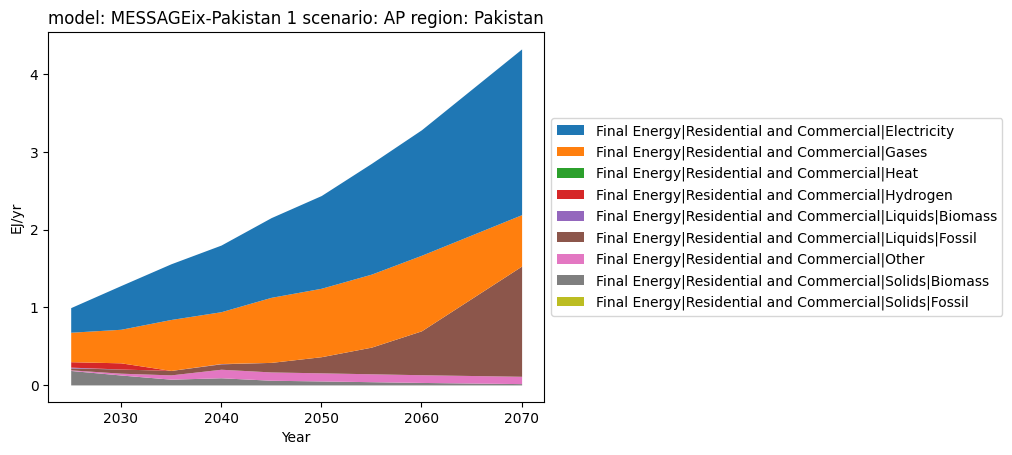

In [15]:
rep_all.filter(variable = vars_SE, scenario='AP').plot.stack()

In [16]:
rep_all.scenario

['AP', 'CurPol', 'ECPC', 'LTS', 'NDC-cond', 'NDC-uncond']

In [17]:
rep_all.filter(variable = 'Final Energy|Transport*').variable

['Final Energy|Transportation',
 'Final Energy|Transportation|Electricity',
 'Final Energy|Transportation|Gases',
 'Final Energy|Transportation|Hydrogen',
 'Final Energy|Transportation|Liquids',
 'Final Energy|Transportation|Liquids|Biomass',
 'Final Energy|Transportation|Liquids|Fossil',
 'Final Energy|Transportation|Other']